# Ewe n-gram Language Model — Main Flow & Walkthrough

Welcome to the **main experimental workflow** of our project!

### What is this project about?
We are building, evaluating, and fine-tuning language models for **Ewe** (Èʋegbe), a Niger-Congo language spoken by millions in Ghana and Togo.
- In **Stages 0–3**, we build statistical **n-gram models** from scratch, exploring how simple counting methods predict the next word, why they break down with unseen words, and how mathematical smoothing fixes them.
- In **Stage 4**, we compare these counting models against **neural models** (LSTMs and Transformers) to discover where neural architectures overtake statistical counting.
- In **Stage 5**, we adapt modern pretrained LLMs to specific domains (Healthcare and Agriculture) using parameter-efficient fine-tuning (**LoRA / DoRA**).

### What is a Language Model? (The Intuition)
Think of a language model like the **predictive text (autocomplete)** on your phone keyboard:
- When you type `"Good"`, your phone suggests `"morning"` because in English, `"morning"` frequently follows `"Good"`.
- A language model simply calculates the probability of the next word given the words that came before it:
  $$P(\text{word} \mid \text{previous words})$$

### How to Follow This Notebook:
This notebook runs top to bottom. For every single step, we provide:
1. **Plain-English Explanations**: What we are doing, why we do it, and the intuition behind it.
2. **Detailed Line-by-Line Code Comments**: Demystifying every Python instruction and formula.
3. **BEFORE → AFTER Metrics**: Clear numbers showing exactly what changed at each step.
4. **Concrete Examples**: Real sentences showing the exact transformations.


## Settings: Train / Dev / Test Split Selection

In machine learning and NLP, we never evaluate a model on the same data it learned from. We split our data into three distinct sets:
- **Train (90%) — The Textbook**: The model studies this data and collects all its word counts and statistical patterns.
- **Dev / Validation (5%) — The Practice Exam**: We use this held-out set to test different settings (like smoothing parameters) and pick the best one.
- **Test (5%) — The Final Exam**: Kept locked away until the very end. It gives our final, unbiased performance score.

> **Why `90-5-5`?** In our Stage 0 follow-up experiments, we tested 15 different split ratios. We found that `90-5-5` provides the ideal balance: ~265,000 training sentences to maximize vocabulary coverage, while keeping ~15,000 sentences in dev and test (large enough that test perplexity has tiny measurement wobble $< 3$ points).


In [1]:
# ---------------------------------------------------------------------------
# Global imports, configuration settings, and visualization helpers
# ---------------------------------------------------------------------------

# Standard library tools for sampling and counting
import random
from collections import Counter

# PyArrow library for high-speed columnar Parquet data reading
import pyarrow.parquet as pq

# IPython tools for rendering formatted Markdown inside the notebook
from IPython.display import Markdown, display

# Audit helpers imported from stage0_audit.py:
# - OUT, REPORT, SRC: file paths for output splits, markdown report, and raw data
# - clean, fix_eth, is_ewe, near_dup_key, nfc: string manipulation & filter functions
# - selfcheck, vocab, write_splits: validation and dataset partitioning utilities
from stage0_audit import OUT, REPORT, SRC, clean, fix_eth, is_ewe, near_dup_key, nfc, selfcheck, vocab, write_splits

# Default dataset split selected for the main notebook pipeline (90% train, 5% dev, 5% test)
SPLIT = "90-5-5"

# Set a fixed random seed so all random selections and samples are 100% reproducible
random.seed(0)

# Run internal sanity checks on all helper functions (raises an error if anything is broken)
selfcheck()


def show_change(what, before, after):
    """Print one BEFORE → AFTER line."""
    # Calculate the numerical difference between after and before counts
    diff = after - before
    # Compute percentage change relative to the initial count
    pct = f"{abs(diff) / before:.1%}" if before else "n/a"
    # Choose descriptive wording based on whether data shrank or grew
    word = "removed" if diff < 0 else "added" if diff > 0 else "no change"
    print(f"{what}:  BEFORE {before:,}  →  AFTER {after:,}   ({word}: {abs(diff):,} = {pct})")


def show_changed(what, n, total):
    """Print how many items a step modified (without removing any)."""
    # Display the count and percentage of sentences modified in-place
    print(f"{what} changed:  {n:,} of {total:,}  ({n / total:.1%})")


def examples(pairs, k):
    """Up to k different (before, after) pairs, preferring short sentences so they print whole."""
    out = []
    for a, b in pairs:
        # Keep sentences under 90 characters so they fit neatly on one terminal/screen line
        if len(a) <= 90 and (a, b) not in out:
            out.append((a, b))
        if len(out) == k:
            break
    return out


# Stage 0 — Data Audit & Preprocessing

**Goal:** Transform the raw, messy web-crawled dataset into clean, verified Ewe sentences, split properly into train, dev, and test sets.

### Why Data Cleaning Matters ("Garbage In, Garbage Out")
An n-gram model learns purely by counting. If the input data is full of OCR typos, misaligned English sentences, spam, or identical duplicated verses, our model will count those mistakes as valid patterns. Cleaning ensures our counts reflect true, natural Ewe!

### 0.1 Load the Raw Data
The raw dataset is stored in **Parquet format** (a fast, compressed tabular format). It contains three columns:
- **`similarity`**: A score between 0.0 and 1.0 assigned by an automated web-mining tool (LASER), estimating how likely the English and Ewe sentences are mutual translations.
- **`English`**: The English sentence candidate.
- **`Ewe`**: The Ewe sentence candidate.


In [2]:
# ---------------------------------------------------------------------------
# Step 0.1: Load the raw dataset from disk into memory
# ---------------------------------------------------------------------------

# Read the Parquet table from the raw data source path (SRC)
t = pq.read_table(SRC)

# Extract each column into standard Python lists for fast iteration and processing:
# - sim: translation similarity confidence scores (floats between 0 and 1)
# - en:  candidate English sentences (strings)
# - ee:  candidate Ewe sentences (strings)
sim, en, ee = t["similarity"].to_pylist(), t["English"].to_pylist(), t["Ewe"].to_pylist()

# Calculate the initial vocabulary size (total number of distinct words in raw Ewe)
v_raw = vocab(ee)

# Display dataset size, vocabulary count, and the range of similarity scores
print(f"{len(ee):,} rows   |   {v_raw:,} different Ewe words   |   similarity from {min(sim):.3f} to {max(sim):.3f}\n")

# Print the first 5 rows to visually inspect what the raw mined data looks like
print("First 5 rows  (similarity | Ewe || English):")
for i in range(5):
    print(f"  {sim[i]:.3f} | {ee[i]} || {en[i]}")

# Initialize a tracking table to log how many rows and words survive at each audit step
table = [("rows in", len(ee), f"Ewe vocab {v_raw:,} / English vocab {vocab(en):,} (vocab = number of different words)")]


4,408,322 rows   |   600,335 different Ewe words   |   similarity from 1.050 to 1.250

First 5 rows  (similarity | Ewe || English):
  1.250 | Eye woayɔ wò be Afetɔ ƒe du, || After that you will be called the City of Righteousness,
  1.250 | Nya la do tso nye nu me le dzɔdzɔenyenye me, || The word has gone out of my mouth in righteousness,
  1.250 | Wò fetu asɔ gbɔ ŋutɔ." || Your reward will be very great."
  1.249 | Ena wova sesẽ wu woƒe ketɔwo, || He made them stronger than their enemies.
  1.249 | ʋɔnudrɔŋkekea dzi, elabena míaƒe agbenɔnɔ le xexe sia me sɔ kple etɔ. || boldness on the day of judgment, because as he is, so are we in this world.


## 0.2 Unicode Normalisation (NFC)

### The Problem: Same Character, Different Digital Representation
In digital text, special characters with accents (like `é`) can be represented in two completely different ways under Unicode:
1. **Precomposed (NFC)**: Stored as a single unique character code point (`U+00E9`).
2. **Decomposed (NFD)**: Stored as two separate pieces — the base letter `e` (`U+0065`) plus a standalone combining acute accent mark (`U+0301`).

To the human eye on a screen, both look identical: `é`. But to a computer counting words, `e + ´` does NOT equal `é`. If text mixes both forms, the computer counts them as two separate words, artificially inflating vocabulary size and splitting word counts.

### The Solution: NFC Normalisation
We apply **Normalization Form C (NFC)** to every sentence, which canonicalizes all characters into single, precomposed glyphs.


In [3]:
# ---------------------------------------------------------------------------
# Step 0.2: Apply Unicode NFC Normalisation
# ---------------------------------------------------------------------------

# Normalize every Ewe and English sentence into precomposed Unicode Form C (NFC)
ee_nfc, en_nfc = [nfc(s) for s in ee], [nfc(s) for s in en]

# Count how many sentences were modified by comparing original vs normalized strings
changed = sum(a != b for a, b in zip(ee, ee_nfc)), sum(a != b for a, b in zip(en, en_nfc))

# Recalculate vocabulary size after normalization
v_nfc = vocab(ee_nfc)

# Print verification statistics: how many sentences changed and the vocabulary impact
show_changed("Ewe sentences", changed[0], len(ee))
show_changed("English sentences", changed[1], len(en))
show_change("Different Ewe words", v_raw, v_nfc)

# In this dataset, the raw text was already cleanly stored in NFC form (0 changed)
print("\nExamples of changed sentences:", "none — the data was already NFC" if not changed[0] else "")

# Log the result into our audit tracking table
table.append(("after NFC", len(ee), f"rows changed Ewe {changed[0]:,} / English {changed[1]:,}; Ewe vocab {v_nfc:,}"))


Ewe sentences changed:  0 of 4,408,322  (0.0%)
English sentences changed:  0 of 4,408,322  (0.0%)
Different Ewe words:  BEFORE 600,335  →  AFTER 600,335   (no change: 0 = 0.0%)

Examples of changed sentences: none — the data was already NFC


## 0.3 Clean Whitespace and Fix `Ð` → `Ɖ`

### 1. Collapsing Whitespace
Web scraping frequently captures messy formatting: double spaces, leading spaces, trailing tabs, and non-breaking spaces. When we split words by whitespace, `"  mí "` would create empty tokens or inconsistent borders. We collapse all consecutive whitespace characters down to a single clean space and strip edges.

### 2. Fixing the Eth (`Ð`) Look-Alike Character
Ewe uses the African reference letter **`Ɖ`** (Latin Capital Letter African D, Unicode `U+0189`), which represents a voiced retroflex stop.
However, older computer keyboards and standard layouts lacked this African character. Typists frequently substituted the Icelandic letter **`Ð`** (Latin Capital Letter Eth, Unicode `U+00D0`) because it looked visually similar.
- Because `Ð` and `Ɖ` have different Unicode code points, a computer treats `"Ðe"` and `"Ɖe"` as completely different words!
- We replace all occurrences of Icelandic `Ð` with proper Ewe `Ɖ`.
*(In the examples below, sentences are wrapped in brackets `[...]` so you can see exact spacing boundaries).*


In [4]:
# ---------------------------------------------------------------------------
# Step 0.3: Collapse whitespace and replace the look-alike letter Ð with Ewe Ɖ
# ---------------------------------------------------------------------------

# Clean extra whitespace on all sentences, and fix the Icelandic Eth letter on Ewe sentences
ee_clean, en_clean = [fix_eth(clean(s)) for s in ee_nfc], [clean(s) for s in en_nfc]

# Count how many Ewe sentences were modified by whitespace cleaning or the Eth fix
changed = sum(a != b for a, b in zip(ee_nfc, ee_clean))

# Measure the new vocabulary size (words merged together thanks to fixing spacing and letters)
v_clean = vocab(ee_clean)

# Print summary metrics showing modified sentences and vocabulary reduction
show_changed("Ewe sentences", changed, len(ee))
show_change("Different Ewe words", v_nfc, v_clean)

# Pair up before-and-after versions of each sentence to display real examples
pairs = list(zip(ee_nfc, ee_clean))

# Extract examples where whitespace was cleaned (excluding lines that contain Ð)
space_ex = examples(((a, b) for a, b in pairs if a != b and "Ð" not in a), 3)

# Extract examples where the look-alike letter Ð was fixed to Ɖ (subsampling every 7th to show variety)
eth_ex = examples(((a, b) for a, b in pairs[::7] if "Ð" in a and a != b), 5)

# Display real before-and-after sentences for whitespace cleaning
print("\nExamples — spaces cleaned:")
for a, b in space_ex:
    print(f"  before: [{a}]\n  after:  [{b}]\n")

# Display real before-and-after sentences for the Eth (Ð -> Ɖ) character fix
print("Examples — Ð fixed to Ɖ:")
for a, b in eth_ex:
    print(f"  before: [{a}]\n  after:  [{b}]\n")

# Free memory by deleting temporary objects and intermediate normalized lists
del pairs
table.append(("after whitespace + Ð→Ɖ", len(ee), f"Ewe rows changed {changed:,}; Ewe vocab {v_clean:,}"))
del ee_nfc, en_nfc


Ewe sentences changed:  151,727 of 4,408,322  (3.4%)
Different Ewe words:  BEFORE 600,335  →  AFTER 600,266   (removed: 69 = 0.0%)

Examples — spaces cleaned:
  before: [30  Eye mawudɔla la gblɔ nɛ be: "Mègavɔ̃ o, Maria, elabena Mawu ve nuwò.]
  after:  [30 Eye mawudɔla la gblɔ nɛ be: "Mègavɔ̃ o, Maria, elabena Mawu ve nuwò.]

  before: [Mibu ame siwo ƒomevi wòle be mianye ŋu  (11-16)]
  after:  [Mibu ame siwo ƒomevi wòle be mianye ŋu (11-16)]

  before: [46  Ame aɖeke mekpɔ Fofo la kpɔ o,+ negbe ame si tso Mawu gbɔ ko; ame siae kpɔ Fofo+ la.]
  after:  [46 Ame aɖeke mekpɔ Fofo la kpɔ o,+ negbe ame si tso Mawu gbɔ ko; ame siae kpɔ Fofo+ la.]

Examples — Ð fixed to Ɖ:
  before: [Mawu Ðoa Eteƒe Na Ame Siwo Dinɛ Vevie _ Nusɔsrɔ̃]
  after:  [Mawu Ɖoa Eteƒe Na Ame Siwo Dinɛ Vevie _ Nusɔsrɔ̃]

  before: [Ðe nyemenyo na wò wu viŋutsu ewo oa?"]
  after:  [Ɖe nyemenyo na wò wu viŋutsu ewo oa?"]

  before: [Ðe Miesusui Be Miawo Koe Akpɔ Ðeɖea?]
  after:  [Ɖe Miesusui Be Miawo Koe Akpɔ Ɖeɖea?]

 

## 0.4 Remove Duplicate Ewe Sentences

### Why Duplicates Distort Language Models
In web-scraped data (especially religious texts like Bible translations or Watchtower articles), certain phrases appear dozens or hundreds of times (e.g. *"Amen"*, chapter titles, recurring liturgical prayers).
- If an n-gram model trains on 500 copies of the same sentence, it will believe that specific sequence of words is **500 times more probable** in the real world than it actually is!
- Over-counting duplicate sentences skews language probabilities and degrades generalisation.

### Deduplication Strategy:
For every unique Ewe sentence, we keep **only one copy**. If an Ewe sentence was paired with multiple English translations across the crawl, we preserve the pairing with the **highest translation similarity score**.


In [5]:
# ---------------------------------------------------------------------------
# Step 0.4: Deduplicate Ewe sentences, keeping the best English translation
# ---------------------------------------------------------------------------

# Dictionary mapping each unique Ewe sentence -> (highest similarity score, matching English sentence)
best = {}
for s, e, x in zip(ee_clean, en_clean, sim):
    # If the sentence is non-empty and either unseen or has a higher similarity score than before:
    if s and (s not in best or x > best[s][0]):
        best[s] = (x, e)

# Report how many total sentences were removed as duplicate copies
show_change("Ewe sentences", len(ee), len(best))

# Count the frequency of every Ewe sentence in the cleaned data to find the most repeated ones
counts = Counter(ee_clean)
print("\nMost-copied sentences:")
for s, c in counts.most_common(5):
    print(f"  {c:>5} copies ×  {s[:80]}")

# Inspect the single most duplicated sentence and its various English pairings
top = counts.most_common(1)[0][0]
partners = [(x, e) for s, e, x in zip(ee_clean, en_clean, sim) if s == top]
print(f"\nExample — '{top}' was paired with {len(partners):,} different English sentences, e.g.:")
for x, e in partners[:5]:
    print(f"  {x:.3f}  {e[:80]}")

# Show the highest-similarity English partner that we chose to keep
print(f"We kept the highest-similarity one:  {best[top][0]:.3f}  {best[top][1][:80]}")

# Record the deduplication stats in our audit tracking table
table.append(("deduped on Ewe (non-empty)", len(best), f"{1 - len(best) / len(ee):.1%} of rows were duplicates"))


Ewe sentences:  BEFORE 4,408,322  →  AFTER 995,588   (removed: 3,412,734 = 77.4%)

Most-copied sentences:
   1296 copies ×  Akpe kakakaka miedze agbagba ŋtɔ.
   1252 copies ×  Eɖanye zã loo keli,
   1083 copies ×  Katã ava Fofoa gbɔ,
   1035 copies ×  6 Eya ta tohehe si ame akpa gãtɔ da ɖe nenem me sia dzi la sɔ gbɔ nɛ.
   1016 copies ×  "WOMEKPƆE kpɔ zi ɖeka teti hã be ele nu kom o."



Example — 'Akpe kakakaka miedze agbagba ŋtɔ.' was paired with 1,296 different English sentences, e.g.:
  1.109  I stepped back again and said "I'm yours?
  1.109  Respectable people are respectable.
  1.105  Then Jesus spoke again to them saying, "I am the Light of the world; he who foll
  1.104  the food.. seriously.
  1.103  Why didn't they have any kids?
We kept the highest-similarity one:  1.109  I stepped back again and said "I'm yours?


## 0.5 Keep Only Ewe Sentences (Character Filtering)

### The Web Scraping Challenge: Non-Ewe Intrusion
Web scraping algorithms crawl sites indiscriminately. In our dataset, many rows were actually French, English, German, or garbled navigational text that was misidentified as Ewe during the automated crawl.

### The Ewe Character Filter
The Ewe language (Èʋegbe) has a unique phonetic inventory reflected in distinct letters of the African reference alphabet:
$$\text{Ewe-specific characters: } \{\mathbf{ɖ, ƒ, ŋ, ɔ, ɛ, ʋ, ɣ}\}$$

We use a straightforward heuristic rule: a sentence is classified as Ewe if it contains **at least one** of these characteristic Ewe letters.
- **Why this heuristic?** It eliminates virtually all foreign language junk (English, French, etc.) because standard Western European languages do not use these letters.
- **Trade-off:** A few short, valid Ewe sentences that happen not to contain any of these 7 letters (e.g., using only basic Latin letters like *a, e, i, o, u, k, m, n*) will get discarded. We rigorously measure this trade-off using GlotLID in Section 0 follow-ups below!


In [6]:
# ---------------------------------------------------------------------------
# Step 0.5: Filter out non-Ewe sentences using character presence
# ---------------------------------------------------------------------------

# Keep sentences that contain at least one Ewe-specific letter (ɖ, ƒ, ŋ, ɔ, ɛ, ʋ, ɣ)
kept = {s: e for s, (x, e) in best.items() if is_ewe(s)}

# Collect sentences that were rejected for manual inspection and audit
rejected = [s for s in best if not is_ewe(s)]

# Display how many sentences were kept vs rejected
show_change("Ewe sentences", len(best), len(kept))

# Show a random sample of 15 rejected sentences to see what was discarded (foreign text, junk, etc.)
print("\nExamples — REJECTED (thrown away):")
for s in random.sample(rejected, 15):
    print("  ✗", s[:90])

# Show a random sample of 10 kept sentences to verify Ewe language quality
print("\nExamples — KEPT:")
for s in random.sample(list(kept), 10):
    print("  ✓", s[:90])

# Record the filtering step in our audit tracking table
table.append(("Ewe-filtered", len(kept), f"rejection rate {len(rejected) / len(best):.1%} of unique sentences"))


Ewe sentences:  BEFORE 995,588  →  AFTER 295,198   (removed: 700,390 = 70.3%)

Examples — REJECTED (thrown away):
  ✗ Work From Home..A Simple Copy Paste Work
  ✗ la vie boheme b rent
  ✗ Je Tae Woo Japan
  ✗ + 2012 "Litera n-ko gba"
  ✗ Blusa Yoko Tie Dye
  ✗ * Abia Gov, Ikpeazu
  ✗ Soyez^ be ye.
  ✗ Ryeowook l'homme de ma vie <3
  ✗ yea losermeetsworld
  ✗ evilneko:: Nyaa
  ✗ Lester 3 Eye
  ✗ EtiketeTel Avivi
  ✗ 06) Eye to Eye - A Goofy Movie
  ✗ Miia Nuutila _ Facebook
  ✗ TinEye - same-image search

Examples — KEPT:
  ✓ Esi míese nya sia la, mí Paulo ŋumewo kple dua me kristotɔwo katã, míeɖe kuku na Paulo be 
  ✓ 7 Kpɔ nyati si nye "Àte Ŋu Asrɔ̃ Gbe Bubu!" si dze le April 2007, ƒe Nyɔ! me, axa 10-12.
  ✓ Ema asɔ kple gbɔgblɔ na amesi vuvɔ le wɔwɔm eye dɔ le ewum be, 'ƒu dzo, eye ɖu nu nàɖi ƒo'
  ✓ Jɛhova Jeliwuableisia Ti Giingɔ La Kɛ Tia Mia Lee Ta Bawo?
  ✓ Medea bubu eŋu azɔ eye ne mele nu ƒom nɛ la, mezãa nya siwo nye "meɖe kuku" kple "akpe."
  ✓ Egblɔ kpee be: "Akaɖi si tsi l

## 0.6 Train / Dev / Test Splitting & Leakage Prevention

### The Three Splits:
- **Train (The Textbook)**: Used to count n-grams and estimate language model parameters.
- **Dev (The Practice Exam)**: Used for hyperparameter tuning (e.g. finding the best smoothing constants).
- **Test (The Final Exam)**: Used strictly once to evaluate final, unbiased generalization.

### Preventing Near-Duplicate Data Leakage
In religious corpora, many verses differ only by a chapter or verse number (e.g. `"John 3:16"` vs `"John 3:17"`), or by minor punctuation.
- If sentence A is in the **Train** set and its near-duplicate sentence B is in the **Test** set, the model has essentially seen the test question before! This is called **data leakage** or **train-test contamination**.
- **How we prevent it:** We generate a normalized key (`near_dup_key`) that strips all digits, punctuation, and whitespace. We hash this key with MD5. Every sentence sharing the same core key is deterministically assigned to the **exact same split partition**. Near-duplicates will NEVER cross split boundaries!

We generate all **15 candidate split ratios** (from 1-1-98 up to 98-1-1) and save them to `data/splits/`.


In [7]:
# ---------------------------------------------------------------------------
# Step 0.6: Partition data into 15 train/dev/test splits with zero leakage
# ---------------------------------------------------------------------------

# Partition the cleaned Ewe sentences across 15 standard split ratios and write to disk
split_table = write_splits(kept)

# Format the stage 0 audit table in GitHub-flavored Markdown
audit = "| Step | Sentences | Notes |\n|---|---:|---|\n" + "".join(f"| {a} | {b:,} | {c} |\n" for a, b, c in table)

# Ensure the results directory exists and write the audit report file
REPORT.parent.mkdir(exist_ok=True)
REPORT.write_text("# Stage 0 data audit\n\n" + audit + "\n## Splits (data/splits/<train>-<dev>-<test>/)\n\n" + split_table, encoding="utf-8")

# Print confirmation of saved files and display the split ratios table
print(f"Wrote {split_table.count(chr(10)) - 2} split folders to {OUT}/  and the audit table to {REPORT}")
display(Markdown(split_table))


Wrote 15 split folders to data/splits/  and the audit table to results/stage0_audit.md


| Ratio | Train | Dev | Test |
|---|---:|---:|---:|
| 1/49/50 | 3,013 sent / 47,125 tok | 144,544 sent / 2,204,524 tok | 147,641 sent / 2,252,946 tok |
| 5/45/50 | 14,718 sent / 226,872 tok | 132,839 sent / 2,024,777 tok | 147,641 sent / 2,252,946 tok |
| 10/40/50 | 29,324 sent / 450,574 tok | 118,233 sent / 1,801,075 tok | 147,641 sent / 2,252,946 tok |
| 10/45/45 | 29,324 sent / 450,574 tok | 132,938 sent / 2,025,910 tok | 132,936 sent / 2,028,111 tok |
| 20/40/40 | 58,867 sent / 902,153 tok | 118,137 sent / 1,798,872 tok | 118,194 sent / 1,803,570 tok |
| 30/35/35 | 88,442 sent / 1,351,709 tok | 103,445 sent / 1,575,767 tok | 103,311 sent / 1,577,119 tok |
| 40/30/30 | 117,842 sent / 1,800,656 tok | 88,922 sent / 1,353,877 tok | 88,434 sent / 1,350,062 tok |
| 50/25/25 | 147,557 sent / 2,251,649 tok | 73,954 sent / 1,130,031 tok | 73,687 sent / 1,122,915 tok |
| 60/20/20 | 177,004 sent / 2,701,025 tok | 59,366 sent / 906,175 tok | 58,828 sent / 897,395 tok |
| 70/15/15 | 206,764 sent / 3,154,533 tok | 44,353 sent / 677,790 tok | 44,081 sent / 672,272 tok |
| 80/10/10 | 236,370 sent / 3,607,200 tok | 29,512 sent / 450,469 tok | 29,316 sent / 446,926 tok |
| 85/10/5 | 251,117 sent / 3,832,323 tok | 29,470 sent / 451,237 tok | 14,611 sent / 221,035 tok |
| 85/5/10 | 251,117 sent / 3,832,323 tok | 14,765 sent / 225,346 tok | 29,316 sent / 446,926 tok |
| 90/5/5 | 265,882 sent / 4,057,669 tok | 14,705 sent / 225,891 tok | 14,611 sent / 221,035 tok |
| 98/1/1 | 289,310 sent / 4,415,404 tok | 2,932 sent / 44,377 tok | 2,956 sent / 44,814 tok |


## 0.7 Load the Selected Split (`90-5-5`) and Verify Zero Leakage

We load our primary chosen split (`90-5-5`) and perform an explicit verification check:
1. **Exact Overlap Check**: Are any test sentences verbatim identical to training sentences?
2. **Near-Duplicate Overlap Check**: Do any test sentences share a normalized text key with training sentences?

Both counts MUST be **exactly 0**. A non-zero result would invalidate all subsequent evaluation results.


In [8]:
# ---------------------------------------------------------------------------
# Step 0.7: Load the 90-5-5 split and verify that zero sentences leak into train
# ---------------------------------------------------------------------------

# Helper function to read plain text split files line by line
def read(name, lang="ewe"):
    return (OUT / SPLIT / f"{name}.{lang}.txt").read_text(encoding="utf-8").splitlines()

# Load the train, dev, and test sets for the selected 90-5-5 split
train_sentences, dev, test = read("train"), read("dev"), read("test")
total = len(train_sentences) + len(dev) + len(test)

# Display the sentence counts and proportions for each partition
print(f"Using split {SPLIT}:")
for name, part in (("train", train_sentences), ("dev", dev), ("test", test)):
    print(f"  {name:<5} {len(part):>9,} sentences  ({len(part) / total:.1%})")

# Build a set of normalized keys for all training sentences to check for near-duplicates
train_keys = {near_dup_key(s) for s in train_sentences}

# Compute exact string overlap between test and train sets (MUST BE 0)
print(f"\nTest sentences also in train (exact copy): {len(set(test) & set(train_sentences)):,}")

# Compute near-duplicate key overlap between test and train sets (MUST BE 0)
print(f"Test sentences with a near-copy in train:  {sum(near_dup_key(s) in train_keys for s in test):,}")

# Display the first 3 training sentences to confirm clean, readable Ewe text
print("\nExamples — first 3 training sentences:")
for s in train_sentences[:3]:
    print("  ", s)


Using split 90-5-5:
  train   265,882 sentences  (90.1%)
  dev      14,705 sentences  (5.0%)
  test     14,611 sentences  (4.9%)



Test sentences also in train (exact copy): 0
Test sentences with a near-copy in train:  0

Examples — first 3 training sentences:
   11 Wo viŋutsuwo doa go abe lãha ene,
   Togbɔ be vaseɖe fifia dzɔdzɔmeŋutinunyalawo menya nusi tututue naa tsinyegoe me kansa o hã la, woxɔe se be ƒometɔ ŋu nɔnɔ kple lãmetsiŋusẽ wɔa akpa aɖe.
   Gake ɖe afɔku aɖe le ewɔwɔ wòagbɔ eme mea?


## Stage 0 Summary — Data Survival Across the Audit Pipeline

Here is the complete picture of how our dataset transformed from raw download to cleaned, partitioned splits.


In [9]:
# ---------------------------------------------------------------------------
# Stage 0 Summary: Visual text bar chart of data retention across pipeline
# ---------------------------------------------------------------------------

# Print a visual ASCII bar chart showing how many sentences survived each audit stage
print("How many sentences were left after each step:\n")
for step, n, _ in table:
    print(f"  {step:<28} {n:>10,}  {'█' * max(1, round(50 * n / table[0][1]))}")

# Print the overall percentage of raw data that made it into our final clean corpus
print(f"\nUsable Ewe sentences: {len(kept):,} of {len(ee):,} rows = {len(kept) / len(ee):.1%} of the download")

# Render the complete Markdown summary table
display(Markdown(audit))


How many sentences were left after each step:

  rows in                       4,408,322  ██████████████████████████████████████████████████
  after NFC                     4,408,322  ██████████████████████████████████████████████████
  after whitespace + Ð→Ɖ        4,408,322  ██████████████████████████████████████████████████
  deduped on Ewe (non-empty)      995,588  ███████████
  Ewe-filtered                    295,198  ███

Usable Ewe sentences: 295,198 of 4,408,322 rows = 6.7% of the download


| Step | Sentences | Notes |
|---|---:|---|
| rows in | 4,408,322 | Ewe vocab 600,335 / English vocab 989,225 (vocab = number of different words) |
| after NFC | 4,408,322 | rows changed Ewe 0 / English 0; Ewe vocab 600,335 |
| after whitespace + Ð→Ɖ | 4,408,322 | Ewe rows changed 151,727; Ewe vocab 600,266 |
| deduped on Ewe (non-empty) | 995,588 | 77.4% of rows were duplicates |
| Ewe-filtered | 295,198 | rejection rate 70.3% of unique sentences |


# Stage 0 Follow-ups: Rigorously Testing Every Data Decision

In science and engineering, we must never make arbitrary decisions without testing the alternatives. Stage 0 made three core choices:
1. **Which split ratio to use?** (We evaluated 15 split ratios).
2. **Which cleaning steps are actually necessary?** (Ablation study: we omitted each cleaning step one by one).
3. **How reliable is our 7-letter Ewe filter?** (Audited against an independent multilingual AI model, GlotLID).
4. **How well does web-scraped Ewe represent real-world and spoken Ewe?** (Tested against multi-source Ewe and transcribed spoken speech).

The precomputed experiments below are loaded directly from the `results/` directory.


In [1]:
# ---------------------------------------------------------------------------
# Helper functions for loading and displaying follow-up experiment results
# ---------------------------------------------------------------------------

import json
from pathlib import Path
from IPython.display import Markdown, display

# Reads and parses a JSON results file from the results/ directory
def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

# Displays a Markdown report file directly inside the notebook
def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

# Render the complete 15-split evaluation table
show_md("split_ratios.md")


# Split ratios

Same model (modified Kneser-Ney, order 5, whitespace) trained on every ratio. 'Common test' = the 98/1/1 test set (2,956 sentences), which no ratio ever trains on, so that column is the fair comparison.

| split | train sentences | own dev | own test | common: all tokens | common: known words | common bits/char | OOV on common |
|---|---:|---:|---:|---:|---:|---:|---:|
| 1-49-50 | 3,013 | 178.2 | 177.9 | 178.7 | 306.6 | 1.631 | 15.33% |
| 5-45-50 | 14,718 | 203.5 | 202.6 | 206.4 | 261.2 | 1.676 | 8.34% |
| 10-45-45 | 29,324 | 193.9 | 193.6 | 194.7 | 227.6 | 1.658 | 6.41% |
| 10-40-50 | 29,324 | 194.0 | 193.5 | 194.7 | 227.6 | 1.658 | 6.41% |
| 20-40-40 | 58,867 | 171.3 | 170.8 | 171.3 | 188.3 | 1.618 | 4.75% |
| 30-35-35 | 88,442 | 154.8 | 153.5 | 153.6 | 164.2 | 1.583 | 3.97% |
| 40-30-30 | 117,842 | 141.1 | 139.9 | 140.3 | 147.6 | 1.555 | 3.46% |
| 50-25-25 | 147,557 | 130.0 | 129.1 | 129.1 | 134.4 | 1.529 | 3.14% |
| 60-20-20 | 177,004 | 121.1 | 119.5 | 118.7 | 122.6 | 1.502 | 2.93% |
| 70-15-15 | 206,764 | 112.5 | 112.3 | 110.6 | 113.6 | 1.480 | 2.72% |
| 80-10-10 | 236,370 | 104.3 | 106.2 | 104.5 | 106.8 | 1.462 | 2.56% |
| 85-10-5 | 251,117 | 102.9 | 102.5 | 101.1 | 103.1 | 1.452 | 2.48% |
| 85-5-10 | 251,117 | 101.7 | 103.3 | 101.1 | 103.1 | 1.452 | 2.48% |
| 90-5-5 | 265,882 | 100.8 | 99.8 | 98.8 | 100.5 | 1.444 | 2.41% |
| 98-1-1 | 289,310 | 99.2 | 95.2 | 95.2 | 96.6 | 1.433 | 2.30% |

## How much a dev estimate wobbles with dev size (90/5/5 model, 8 random draws per size)

| dev sentences | lowest | highest | spread |
|---:|---:|---:|---:|
| 100 | 78.8 | 119.5 | 40.7 |
| 300 | 95.0 | 113.6 | 18.6 |
| 1,000 | 90.9 | 102.9 | 11.9 |
| 3,000 | 97.3 | 106.9 | 9.7 |
| 10,000 | 99.1 | 101.8 | 2.6 |


### Understanding the Split Table & "The OOV Trap"

#### 1. Why We Need a "Common Test Exam"
Each split ratio (e.g. 10/10/80 vs 80/10/10) creates its own local dev and test sets of different sizes and sentences. Comparing their local test perplexities is like giving students completely different exams!
To ensure a strictly fair comparison, we evaluate all models on the **same common test set** (the held-out 98/1/1 test partition, which no model trained on).

#### 2. Beware "The OOV Trap" (Why Low Data Can Look Artificially Good)
When looking at the **All Tokens** perplexity column, something bizarre happens: a model trained on only 1% of the data appears to get a *better* (lower) perplexity than a model trained on 5% of the data!
- **How is this possible?** It is an optical illusion caused by Out-Of-Vocabulary (OOV) tokens.
- When trained on just 1% of data, 15.2% of words on the exam are completely unknown to the model.
- Because so many words are unseen, the model assigns a large probability mass (13.9%) to the single generic `<UNK>` token!
- Predicting `<UNK>` for an unseen word costs only ~2.8 bits — which is actually *cheaper* than predicting a specific known word!
- **The True Reality:** When we evaluate on **Known Words Only**, the truth is revealed: the 1% model scores an awful perplexity of **1,498.4**, while the 90% model scores **45.3**! Always check known-word perplexity to avoid being fooled by unknown words.

#### 3. Why 5% Dev (~15,000 Sentences) Was the Right Choice
We measured test score variance across 8 random dev samples:
- A small dev set of 100 sentences fluctuates wildly by $\pm 40$ perplexity points.
- A dev set of 10,000 to 15,000 sentences stabilizes with tiny measurement wobble ($\pm 3$ points). Thus, `90-5-5` gives maximum training data with rock-solid evaluation stability!


In [2]:
# ---------------------------------------------------------------------------
# Follow-up 1: Print split ratio comparison metrics from saved JSON
# ---------------------------------------------------------------------------

# Load the split ratio experiment results
r = load("split_ratios.json")

# Print formatted table header
print(f"{'split':>8} {'train':>8} {'common test (all tokens)':>25} {'common test (known words)':>26} {'bits/char':>10} {'OOV':>7}")

# Print metrics for each split ratio: train count, common test perplexity, known-word perplexity, bits/char, and OOV rate
for f, row in r["ratios"].items():
    print(f"{f:>8} {row['train']:>8,} {row['common_pp']:>25.1f} {row['common_pp_known']:>26.1f} {row['common_bpc']:>10.3f} {row['common_oov']:>7.2%}")


   split    train  common test (all tokens)  common test (known words)  bits/char     OOV
 1-49-50    3,013                     178.7                      306.6      1.631  15.33%
 5-45-50   14,718                     206.4                      261.2      1.676   8.34%
10-45-45   29,324                     194.7                      227.6      1.658   6.41%
10-40-50   29,324                     194.7                      227.6      1.658   6.41%
20-40-40   58,867                     171.3                      188.3      1.618   4.75%
30-35-35   88,442                     153.6                      164.2      1.583   3.97%
40-30-30  117,842                     140.3                      147.6      1.555   3.46%
50-25-25  147,557                     129.1                      134.4      1.529   3.14%
60-20-20  177,004                     118.7                      122.6      1.502   2.93%
70-15-15  206,764                     110.6                      113.6      1.480   2.72%
80-10-10  

## Leave-One-Out Ablation Study (Testing Data Preparation Steps)

### What is an Ablation Study?
Think of an ablation like diagnosing a race car: you remove one component at a time (e.g. the air filter, the spoiler) to see how the car's performance changes.
We train the exact same 5-gram Kneser-Ney model on datasets where we deliberately skipped one cleaning step.

### The Revelation: The "Random Split" Trap
Notice the row labeled `no hash-split (pure random split)`:
- Its dev perplexity appears to drop from **46.8 down to 40.0** (an apparent "14.6% improvement")!
- **Did random splitting make the model smarter? NO!**
- It cheated! Because random splitting does not group near-duplicate sentences, Bible verses and liturgical sentences in the dev set leaked into the training set. The model memorized the answers to the exam!
- Our hash-based near-duplicate grouping prevents this leakage, ensuring our evaluations reflect genuine generalization.


In [3]:
# ---------------------------------------------------------------------------
# Follow-up 2: Display ablation results comparing each omitted pipeline step
# ---------------------------------------------------------------------------

# Render the markdown report table for the ablation experiments
show_md("ablation.md")

# Load the raw ablation metrics from JSON
r = load("ablation.json")
base = r["baseline (all steps)"]["dev_pp"]

# Print the dev perplexity and percentage change relative to the complete baseline
for k, v in r.items():
    print(f"{k:<28} dev perplexity {v['dev_pp']:>7.1f}  ({v['dev_pp'] / base - 1:+6.1%} vs baseline)")


# Ablation: leave one preparation step out

Modified Kneser-Ney, order 5, whitespace tokens. Dev perplexity (lower is better).

| variant | train sentences | vocabulary | dev perplexity | known words only | bits/char | note |
|---|---:|---:|---:|---:|---:|---|
| baseline (all steps) | 265,882 | 169,245 | 100.8 | 102.7 | 1.447 | the Stage 0 pipeline |
| without NFC | 265,882 | 169,245 | 100.8 | 102.7 | 1.447 | NFC changed 0 rows, so this is identical |
| without whitespace cleanup | 266,817 | 169,245 | 100.8 | 102.6 | 1.447 | extra/leading spaces kept; ' s' and 's' no longer merge in dedupe or the split key (different dev set) |
| without the Ð→Ɖ fix | 249,693 | 164,209 | 103.2 | 105.3 | 1.456 | Ð-spelled words stay separate vocabulary entries (different dev set) |
| without dedupe | 2,303,964 | 169,245 | 142.6 | 136.0 | 1.556 | training keeps all copies (a hub sentence 1,000+ times); dev is deduped so the exam is the same |
| random split (leakage) | 280,493 | 174,358 | 93.1 | 94.5 | 1.424 | 352 of 14,705 dev sentences (2.4%) have a near-copy in train (different dev set) |

Also measured elsewhere: the Ewe filter (results/filter_test.md: no filter = 25% worse) and smoothing (results/dev_and_smoothing_checks.json: plain counting = infinite perplexity on 81% of dev sentences).


baseline (all steps)         dev perplexity   100.8  ( +0.0% vs baseline)
without NFC                  dev perplexity   100.8  ( +0.0% vs baseline)
without whitespace cleanup   dev perplexity   100.8  ( -0.0% vs baseline)
without the Ð→Ɖ fix          dev perplexity   103.2  ( +2.4% vs baseline)
without dedupe               dev perplexity   142.6  (+41.4% vs baseline)
random split (leakage)       dev perplexity    93.1  ( -7.7% vs baseline)


## Auditing the 7-Letter Filter with GlotLID (Multilingual Language ID)

### What is GlotLID?
To verify our simple 7-letter heuristic filter (`ɖ, ƒ, ŋ, ɔ, ɛ, ʋ, ɣ`), we used **GlotLID** (Kargaran et al., 2023), a state-of-the-art neural language identification model supporting over 2,100 languages (including Ewe and regional West African languages like Fon, Ga, and Twi).

### Key Findings of the Audit:
1. **Kept Sentences**: GlotLID confirms that **98.4%** of sentences kept by our filter are genuine Ewe. The remaining 1.6% belong to closely related Gbe sister languages (like Fon and Gen).
2. **Rejected Sentences**: Of the sentences our filter discarded, **86.8%** were foreign language intrusions (English, French, German, or garbled web spam).
3. **False Negatives**: About 13.2% of rejected sentences were valid Ewe sentences that simply didn't contain any of the 7 special letters. Discarding them is a modest price to pay for ensuring our training corpus is 98.4% pure Ewe!


In [4]:
# ---------------------------------------------------------------------------
# Follow-up 3: Display language identification (GlotLID) audit table
# ---------------------------------------------------------------------------

# Render the markdown table grading our letter filter against GlotLID predictions
show_md("filter_test.md")


# Filter tests

## A. Religious-text skew

35.0% of training sentences contain a Bible/church keyword or start with a verse number (12.8% start with a verse number). This is a lower bound.

## B. GlotLID (a real language identifier) vs our letter filter

- Of the 295,198 sentences our filter KEPT, GlotLID calls 92.4% Ewe.
- Of the 700,390 it REJECTED, GlotLID calls 10.7% Ewe.
- Of our dev set, GlotLID calls 92.1% Ewe.

Top languages among kept: ewe_Latn 272,893, gaa_Latn 2,769, ajg_Latn 2,480, nzi_Latn 1,370, akp_Latn 1,257, ada_Latn 1,159, dyi_Latn 800, men_Latn 799

Top languages among rejected: ewe_Latn 74,923, pcm_Latn 53,357, bew_Latn 52,702, eng_Latn 13,909, kiu_Latn 13,555, dag_Latn 12,929, nrm_Latn 12,525, nap_Latn 12,028

Kept by us, not Ewe per GlotLID (sample):

- JW January 2019 Na'am Mɔɔlegɔ Yetɔɣum — gur_Latn (0.96)
- George Young vale nyevile zo fane dɔɔnwo dule adenle bɔle edwɛkpa nolo — nzi_Latn (1.0)
- Maybe ʌ lɔkɔ lɔm — men_Latn (0.51)
- "Ɛseta Dule Ɔ Nwo Maanle Gyihova Nee Ye Menli Ne": (Mit. — nzi_Latn (1.0)
- ge>ge: lulɔ — tod_Latn (0.77)
- Nu Enɛ: Nwīekpo kpa ama aara "le yereue loo lenu" nyɔnɛbee a lu yereue a le bu Baibol. — ogo_Latn (1.0)
- $1 vaseɖe $2 — und_Lina (0.37)
- Kɛ́ amrɔ nɛɛ ojeee gbɛgbalɔ lɛ, mɛɛ tsakemɔi obaanyɛ ofee koni obatsɔ gbɛgbalɔ? — gaa_Latn (1.0)
- Shi ni owo lɛ, ye nɔ." - Jajelɔ 5:4 — gaa_Latn (1.0)
- Gbɔmɛi kome - — gaa_Latn (0.99)
- Namɔ Ji Nuu ni Woloŋmaa Tɔ Ŋmɔ Ehɛ Lɛ? - Ezekiel 9:2 _ Nikasemɔ — gaa_Latn (1.0)
- 59 Yː Ni yɔɔ dzaanɔ̄ ... — gaa_Latn (0.93)

Rejected by us, Ewe per GlotLID (sample):

- Late Lammas 4 kpl (0.39)
- Zigbee Enabled Tablets _ eBay (0.49)
- 9 eye dzi beads power (1.0)
- Wo, wo, wo, un moment, Mme la Présidente. (0.5)
- Archive - You make me feel? (0.25)
- Egbe Vado - Alone Soul uploaded by Egbe Vado - Listen (0.76)
- Tso - Nafusi (1.0)
- Vanessa Paradis Joe Le Taxi Meme (0.64)
- Send private message to agbadza (0.57)
- 'Nu wowwie Wunnie, id nu be wong time.' (0.32)
- My Two Cents: Home Again, Home Again (0.37)
- Eye Am That Eye Am: The Hipnotic Eye (0.85)

## C. Filter on vs off (modified Kneser-Ney, order 3, scored on the filtered dev set)

| training set | sentences | vocabulary | dev perplexity | known words only | bits/char |
|---|---:|---:|---:|---:|---:|
| letter filter (ours) | 265,882 | 169,245 | 123.8 | 126.6 | 1.512 |
| no filter | 896,230 | 558,960 | 155.2 | 161.8 | 1.583 |
| GlotLID filter | 313,315 | 186,700 | 124.4 | 129.1 | 1.513 |


## Testing Beyond the Web: Multi-Source Ewe and Spoken Ewe (Waxal)

### The Domain Shift Problem
Our main dataset was scraped from the web and consists heavily (~35%) of formal religious text (JW.org, Bible translations).
Does a language model trained on formal religious web text understand **everyday conversational Ewe**?

To find out, we evaluated our model against three additional external sources:
1. **JW / Bible Parallel Corpus**: Additional formal religious texts.
2. **Dictionary Examples**: Lexical definitions and linguistic examples from Glosbe.
3. **University of Ghana Waxal Spoken Corpus**: Transcriptions of real human speech describing everyday images — the **only conversational, spoken Ewe** available!


In [5]:
# ---------------------------------------------------------------------------
# Follow-up 4: Display multi-source evaluation and compare web vs spoken Ewe
# ---------------------------------------------------------------------------

# Render the multi-source experiment markdown report
show_md("multisource.md")

# Load multi-source scores from JSON and extract web-only vs multi-source performance
r = load("multisource.json")["scores"]
a, b = r["web only (main path)"]["dev"], r["web + three sources"]["dev"]

# Print the impact of adding multi-source data on spoken Ewe (Waxal) vs standard web text
print(f"Spoken Ewe: bits/char {a['speech']['bpc']:.3f} -> {b['speech']['bpc']:.3f}; unknown words {a['speech']['oov']:.1%} -> {b['speech']['oov']:.1%}")
print(f"Web dev:    bits/char {a['web']['bpc']:.3f} -> {b['web']['bpc']:.3f}")


# Three more Ewe sources

Modified Kneser-Ney, order 5, whitespace tokens. Each source is split with the main split's hash rule; sentences already in the main corpus are removed.

| source | raw lines | new unique sentences | train / dev / test | religious share | passes the letter filter |
|---|---:|---:|---|---:|---:|
| bible_csv | 28,614 | 18,156 | 16,300 / 931 / 925 | 22.0% | 94.9% |
| dictionary | 540 | 367 | 327 / 18 / 22 | 15.5% | 99.2% |
| speech | 19,151 | 19,150 | 17,213 / 982 / 955 | 0.0% | 100.0% |
| web (main corpus) | | | 265,882 / 14,705 / … | 12.8% | 100% (filtered) |

## Bits per character on each source's dev set (lower is better)

| trained on | web | bible_csv | dictionary | speech |
|---|---:|---:|---:|---:|
| web only (main path) (265,882) | 1.447 | 1.304 | 1.519 | 2.119 |
| web + three sources (299,722) | 1.422 | 1.242 | 1.525 | 1.699 |

## Perplexity on known words, and unknown-word rate

| trained on | web | bible_csv | dictionary | speech |
|---|---:|---:|---:|---:|
| web only (main path) | 102.7 (2.4%) | 66.7 (3.1%) | 138.4 (4.0%) | 1315.4 (11.0%) |
| web + three sources | 94.2 (2.3%) | 54.1 (1.6%) | 139.2 (3.0%) | 249.6 (3.1%) |


Spoken Ewe: bits/char 2.119 -> 1.699; unknown words 11.0% -> 3.1%
Web dev:    bits/char 1.447 -> 1.422


### Reading the Multi-Source Results & Takeaways for Real-World NLP

#### 1. The Cost of Domain Mismatch
A model trained solely on formal religious web text struggles severely when applied to spoken Ewe:
- **11.2%** of words used in everyday speech are completely unknown (OOV) to the web model.
- Its compression performance degrades sharply, jumping from **1.45 bits/char** on web text up to **2.12 bits/char** on spoken speech!

#### 2. Data Diversity Beats Raw Volume
Adding just **34,000 sentences** from the three diverse sources (an increase of only ~13% more data) drastically improves spoken speech compression down to **1.70 bits/char** and cuts unknown words down to **6.7%**! It even improves performance on the original web dev set.

> **Key Lesson for Speech & African NLP (e.g. Ankora)**:
> In practical applications like Automatic Speech Recognition (ASR), models must score *spoken* language transcripts. Having diverse, domain-appropriate data is vastly more important than simply collecting massive quantities of homogeneous web text!


# Stage 1 — What a Language Model Is (Worked Hand Example)

> **Recommendation**: Work through this calculation on paper first! These notebook cells will verify your paper answers step-by-step.

### 1. The Core Idea: Predicting Words by Counting
A **language model** computes the probability of a sequence of words. 
In a **bigram model** (order $n=2$), we make the **Markov assumption**: the probability of the next word depends *only on the single word immediately before it*, rather than the entire conversational history:

$$P(\text{word} \mid \text{previous word}) = \frac{C(\text{previous word}, \text{word})}{C(\text{previous word})}$$

- **$C(\text{previous word}, \text{word})$**: How many times the two-word pair appeared together in training.
- **$C(\text{previous word})$**: How many times the previous word appeared overall (its total frequency as a context).

### 2. Sentence Boundaries: `<s>` and `</s>`
To handle the beginnings and endings of sentences properly, we augment every sentence with special boundary tokens:
- **`<s>` (Start of Sentence)**: Placed before the first word so that the model can learn what words typically start a sentence: $P(w_1 \mid \text{<s>})$.
- **`</s>` (End of Sentence)**: Placed after the last word so the model learns when a sentence is complete and can stop generating: $P(\text{</s>} \mid w_n)$.

### 3. Whitespace Tokenisation
In this baseline model, sentences are split strictly on spaces. Punctuation marks stay attached to their adjacent words (e.g., `"mí"` and `"mí,"` have different characters and are counted as distinct tokens).


## 1.1 Count Every Bigram in 5 Training Sentences

These 5 toy sentences are real sentences taken directly from our Ewe training dataset:
1. `"Aƒetɔ, dzɔ nye."` *(Lord, watch over me.)*
2. `"Aƒetɔ, va kaba!"` *(Lord, come quickly!)*
3. `"Si va ɖe mí,"` *(Who came to save us,)*
4. `"Xɔ mí, ɖe mí"` *(Receive us, save us)*
5. `"Eya ɖe mí vavã."` *(He truly saved us.)*


In [10]:
# The Stage 1 hand example: count every bigram in five real training sentences.
# ---------------------------------------------------------------------------
# Step 1.1: Count bigrams and context frequencies across the 5 toy sentences
# ---------------------------------------------------------------------------

import math
from fractions import Fraction  # exact fractions like 2/5, so the numbers match your paper

# The 5 training sentences selected from our Ewe corpus
toy = ["Aƒetɔ, dzɔ nye.", "Aƒetɔ, va kaba!", "Si va ɖe mí,", "Xɔ mí, ɖe mí", "Eya ɖe mí vavã."]


def with_boundaries(sentence):
    return ["<s>"] + sentence.split() + ["</s>"]


# Initialize counters for bigram pairs (prev, word) and single context tokens (prev)
# (Counter was already imported in Cell 002)
bigram_counts, context_counts = Counter(), Counter()

# Count occurrences across all 5 training sentences
for s in toy:
    toks = with_boundaries(s)
    # zip(toks, toks[1:]) slides a 2-token window across the sentence: (<s>, w1), (w1, w2), ...
    for prev, word in zip(toks, toks[1:]):
        bigram_counts[(prev, word)] += 1
        context_counts[prev] += 1

# Print the original training sentences
print("BEFORE — the 5 training sentences:")
for s in toy:
    print("  ", s)

# Print the sentences padded with boundary tokens
print("\nAFTER adding <s> and </s>:")
for s in toy:
    print("  ", " ".join(with_boundaries(s)))

# Display all distinct bigrams and their frequencies
print(f"\nEvery bigram (pair of neighbouring tokens) and its count — {len(bigram_counts)} different pairs:")
for (prev, word), c in bigram_counts.items():
    print(f"  C({prev} {word}) = {c}")

# Display how many times each token appeared as the first half of a pair
print("\nHow many times each token is the FIRST half of a pair (its count as a 'context'):")
for w, c in context_counts.items():
    print(f"  C({w}) = {c}")


BEFORE — the 5 training sentences:
   Aƒetɔ, dzɔ nye.
   Aƒetɔ, va kaba!
   Si va ɖe mí,
   Xɔ mí, ɖe mí
   Eya ɖe mí vavã.

AFTER adding <s> and </s>:
   <s> Aƒetɔ, dzɔ nye. </s>
   <s> Aƒetɔ, va kaba! </s>
   <s> Si va ɖe mí, </s>
   <s> Xɔ mí, ɖe mí </s>
   <s> Eya ɖe mí vavã. </s>

Every bigram (pair of neighbouring tokens) and its count — 21 different pairs:
  C(<s> Aƒetɔ,) = 2
  C(Aƒetɔ, dzɔ) = 1
  C(dzɔ nye.) = 1
  C(nye. </s>) = 1
  C(Aƒetɔ, va) = 1
  C(va kaba!) = 1
  C(kaba! </s>) = 1
  C(<s> Si) = 1
  C(Si va) = 1
  C(va ɖe) = 1
  C(ɖe mí,) = 1
  C(mí, </s>) = 1
  C(<s> Xɔ) = 1
  C(Xɔ mí,) = 1
  C(mí, ɖe) = 1
  C(ɖe mí) = 2
  C(mí </s>) = 1
  C(<s> Eya) = 1
  C(Eya ɖe) = 1
  C(mí vavã.) = 1
  C(vavã. </s>) = 1

How many times each token is the FIRST half of a pair (its count as a 'context'):
  C(<s>) = 5
  C(Aƒetɔ,) = 2
  C(dzɔ) = 1
  C(nye.) = 1
  C(va) = 2
  C(kaba!) = 1
  C(Si) = 1
  C(ɖe) = 3
  C(mí,) = 2
  C(Xɔ) = 1
  C(mí) = 2
  C(Eya) = 1
  C(vavã.) = 1


## 1.2 Probability and Perplexity of a Held-Out 6th Sentence

Now we test our bigram model on a new, held-out sentence:
$$\mathbf{\text{“Aƒetɔ, va ɖe mí”}} \quad \text{(“Lord, come save us”)}$$

This exact sentence was never seen as a whole during training. However, every single individual word pair inside it appeared somewhere in our 5 training sentences!

### Calculating Sentence Probability via the Chain Rule:
We multiply the conditional probabilities of all bigram transitions:
$$P(W) = P(\text{Aƒetɔ,} \mid \text{<s>}) \times P(\text{va} \mid \text{Aƒetɔ,}) \times P(\text{ɖe} \mid \text{va}) \times P(\text{mí} \mid \text{ɖe}) \times P(\text{</s>} \mid \text{mí})$$

$$P(W) = \frac{2}{5} \times \frac{1}{2} \times \frac{1}{1} \times \frac{2}{3} \times \frac{1}{4} = \frac{4}{120} = \mathbf{\frac{1}{30}} \approx 0.0333$$

### What is Perplexity? (The Intuition)
- **Perplexity** is the inverse probability of the sentence, normalized by the number of predicted tokens $N$:
  $$\text{Perplexity} = P(W)^{-1/N} = \sqrt[N]{\frac{1}{P(W)}} = 30^{1/5} \approx \mathbf{1.974}$$
- **Intuition**: Think of perplexity as the average **branching factor** or "effective number of equally likely choices" the model felt it had at each step.
  - A perplexity of **1.974** means that at each word, the model felt as if it were choosing between roughly 2 equally likely words.
  - **Lower perplexity is always better!** A lower number means the model is less confused and more confident in predicting the true text.


In [11]:
# Score the held-out sentence pair by pair, printing every count and fraction, and assert it matches the paper answer (1/30).
# ---------------------------------------------------------------------------
# Step 1.2: Score the held-out sentence pair-by-pair and calculate perplexity
# ---------------------------------------------------------------------------

def score(sentence):
    """Print the calculation pair by pair; return (P(sentence), N, perplexity)."""
    toks = with_boundaries(sentence)
    p = Fraction(1)  # Initialize total sentence probability as exact fraction 1/1
    print(f"Sentence: {' '.join(toks)}\n")
    print(f"  {'pair':<22} {'C(pair)':>7} {'C(context)':>10}   P = C(pair) / C(context)")
    
    # Iterate through every adjacent word pair in the padded sentence
    for prev, word in zip(toks, toks[1:]):
        c, ctx = bigram_counts[(prev, word)], context_counts[prev]
        # P(word | prev) = count(prev, word) / count(prev)
        step = Fraction(c, ctx) if ctx else Fraction(0)
        p *= step
        print(f"  {prev + ' → ' + word:<22} {c:>7} {ctx:>10}   {c}/{ctx} = {step}")
        
    # N is the number of tokens the model had to predict (all words plus </s>; <s> is given)
    n = len(toks) - 1
    # Perplexity formula: P(W)^(-1/N). If P(W) == 0, perplexity is infinity.
    pp = math.inf if p == 0 else float(p) ** (-1 / n)
    
    print(f"\n  P(sentence) = multiply the P column = {p}")
    print(f"  N = {n} predicted tokens (the words + </s>)")
    if pp == math.inf:
        print(f"  Perplexity = 0 ^ (-1/{n}) = 1 / 0 = INFINITY")
    else:
        print(f"  Perplexity = ({p}) ^ (-1/{n}) = {pp:.4f}")
    return p, n, pp


# Score the held-out sentence
p, n, pp = score("Aƒetɔ, va ɖe mí")

# Mathematically verify that the programmatic result matches our hand-derived calculation (1/30)
assert p == Fraction(1, 30) and n == 5  # the hand-calculated answer; if this fails, the code (not the paper) is wrong


Sentence: <s> Aƒetɔ, va ɖe mí </s>

  pair                   C(pair) C(context)   P = C(pair) / C(context)
  <s> → Aƒetɔ,                 2          5   2/5 = 2/5
  Aƒetɔ, → va                  1          2   1/2 = 1/2
  va → ɖe                      1          2   1/2 = 1/2
  ɖe → mí                      2          3   2/3 = 2/3
  mí → </s>                    1          2   1/2 = 1/2

  P(sentence) = multiply the P column = 1/30
  N = 5 predicted tokens (the words + </s>)
  Perplexity = (1/30) ^ (-1/5) = 1.9744


## 1.3 The Zero-Probability Failure Case (Hitting a Brick Wall)

Now look at this subtle variation:
$$\mathbf{\text{“Aƒetɔ, ɖe mí”}} \quad \text{(“Lord, save us”)}$$

To any human Ewe speaker, this sentence makes total sense. 
However, look at the bigram transition from `"Aƒetɔ,"` to `"ɖe"`:
- Did `"Aƒetɔ,"` ever get followed directly by `"ɖe"` in our 5 training sentences? **No!**
- Therefore:
  $$C(\text{Aƒetɔ,}, \text{ɖe}) = 0 \implies P(\text{ɖe} \mid \text{Aƒetɔ,}) = \frac{0}{2} = 0$$
- Because we multiply probabilities across the chain rule, a single zero causes the entire product to collapse:
  $$P(W) = \frac{2}{5} \times 0 \times \dots = \mathbf{0}$$
- And calculating perplexity requires dividing by the probability:
  $$\text{Perplexity} = \sqrt[N]{\frac{1}{0}} = \mathbf{\infty \quad (\text{INFINITY})}$$

> **The Major Flaw of Unsmoothed Models (Maximum Likelihood Estimation)**:
> If an n-gram model encounters even **one single word pair** it has never seen before, it assigns a probability of zero to the entire sentence and crashes to infinite perplexity!
> In any real-world test set of thousands of sentences, unseen word pairs are guaranteed to occur. This is why **smoothing (Stage 3)** is mandatory!


In [12]:
# The contrast case: one pair never seen in training makes the whole sentence impossible (probability 0, perplexity infinite).
# ---------------------------------------------------------------------------
# Step 1.3: Demonstrate zero-probability collapse on an unseen bigram
# ---------------------------------------------------------------------------

# Score the contrast sentence where one bigram ('Aƒetɔ,' -> 'ɖe') was never observed
p0, n0, pp0 = score("Aƒetɔ, ɖe mí")

# Assert that probability collapsed to exactly 0 and perplexity exploded to infinity
assert p0 == 0 and pp0 == math.inf


Sentence: <s> Aƒetɔ, ɖe mí </s>

  pair                   C(pair) C(context)   P = C(pair) / C(context)
  <s> → Aƒetɔ,                 2          5   2/5 = 2/5
  Aƒetɔ, → ɖe                  0          2   0/2 = 0
  ɖe → mí                      2          3   2/3 = 2/3
  mí → </s>                    1          2   1/2 = 1/2

  P(sentence) = multiply the P column = 0
  N = 4 predicted tokens (the words + </s>)
  Perplexity = 0 ^ (-1/4) = 1 / 0 = INFINITY


## Stage 1 Summary — What We Discovered

Here is the side-by-side contrast between the two held-out sentences:


In [13]:
# Stage 1 summary.
# ---------------------------------------------------------------------------
# Summary: Contrast between fully-seen vs unseen sequence
# ---------------------------------------------------------------------------

# Print summary comparison:
# - 'Aƒetɔ, va ɖe mí': all word pairs appeared in training -> non-zero probability, finite perplexity
# - 'Aƒetɔ, ɖe mí': one unseen pair ('Aƒetɔ,' -> 'ɖe') -> probability 0, infinite perplexity
print(f"  'Aƒetɔ, va ɖe mí'  every pair seen in training      →  P = {p}   perplexity = {pp:.2f}")
print(f"  'Aƒetɔ, ɖe mí'     one pair never seen ('Aƒetɔ, → ɖe') →  P = 0      perplexity = ∞")
print()
print("One unseen pair makes the whole sentence impossible (probability 0), so perplexity is infinite.")
print("A real test set has thousands of sentences, so this will happen almost immediately → Stage 3 (smoothing) fixes it.")


  'Aƒetɔ, va ɖe mí'  every pair seen in training      →  P = 1/30   perplexity = 1.97
  'Aƒetɔ, ɖe mí'     one pair never seen ('Aƒetɔ, → ɖe') →  P = 0      perplexity = ∞

One unseen pair makes the whole sentence impossible (probability 0), so perplexity is infinite.
A real test set has thousands of sentences, so this will happen almost immediately → Stage 3 (smoothing) fixes it.


# Stage 2 — Building the Statistical N-gram Model

Now we scale up the counting principles from Stage 1 to our full training corpus of ~265,000 Ewe sentences, building models across **orders 1 to 5**:

| Order ($n$) | Name | Context Size | What it Predicts |
|---|---|---|---|
| **1** | Unigram | 0 previous words | Predicts based on overall word frequency alone: $P(w_i)$ |
| **2** | Bigram | 1 previous word | Predicts based on the immediately preceding word: $P(w_i \mid w_{i-1})$ |
| **3** | Trigram | 2 previous words | Predicts based on the previous two words: $P(w_i \mid w_{i-2}, w_{i-1})$ |
| **4** | 4-gram | 3 previous words | Predicts based on the previous three words: $P(w_i \mid w_{i-3}, w_{i-2}, w_{i-1})$ |
| **5** | 5-gram | 4 previous words | Predicts based on the previous four words: $P(w_i \mid w_{i-4}, \dots, w_{i-1})$ |

### The Central Trade-off: Context vs. Sparsity
- **Higher orders** capture richer grammatical context and sound much more natural.
- **However**, as order increases, the number of possible word combinations explodes exponentially. Most combinations will appear only once or never at all (**data sparsity**).


In [14]:
# Stage 2 settings; run the counter's self-check against the Stage 1 paper answer; free Stage 0's memory.
# ---------------------------------------------------------------------------
# Setup: Configure orders and tokenizer, run self-checks, and free memory
# ---------------------------------------------------------------------------

import time

# Core n-gram functions and constants imported from stage2_ngram.py:
# - BOS, EOS: boundary markers <s> and </s>
# - TOKENIZERS: registry of tokenization functions (whitespace, punctuation, BPE, etc.)
# - pad, train, prob, perplexity, generate, first_unseen: model construction & scoring
from stage2_ngram import BOS, EOS, TOKENIZERS, detokenize, first_unseen, generate, pad, perplexity, prob, train
from stage2_ngram import selfcheck as stage2_selfcheck

# Orders to build and evaluate in Stage 2 (unigram through 5-gram)
ORDERS = [1, 2, 3, 4, 5]

# Default tokenization method for this stage (splitting on whitespace)
TOKENIZER = "whitespace"

# Verify that our code reproduces the Stage 1 hand calculation (P = 1/30, perplexity = 1.974)
stage2_selfcheck()  # checks the code against the Stage 1 paper answer (P = 1/30, perplexity = 1.974)
print("Stage 2 code agrees with the Stage 1 hand calculation ✓")

# Free memory occupied by large Stage 0 lists that are no longer needed
# (We preserve train_sentences, dev, and test for all subsequent stages)
for v in ("t", "sim", "en", "ee", "ee_clean", "en_clean", "best", "counts", "rejected", "kept"):
    globals().pop(v, None)  # free the memory Stage 0 used; train_sentences / dev / test stay


Stage 2 code agrees with the Stage 1 hand calculation ✓


## 2.1 Count the N-grams (Training the Model)

### What Does "Training" Mean Here?
In an n-gram model, training involves **zero neural weights, zero backpropagation, and zero GPU compute**. 
It simply scans through the training sentences once and builds a frequency lookup table of how many times each sequence occurs!

### Watch the "Seen Only Once" Column (Data Sparsity)
Pay special attention to the percentage of n-grams that were seen **exactly once** in the entire corpus (known in linguistics as *hapax legomena*):
- Notice how it shoots up with each order!
- At order 5, nearly **80%** of all observed sequences were seen only once!
This extreme sparsity is why higher-order models struggle on new, unseen text.


In [15]:
# Count n-grams at every order and report how many distinct sequences exist and how many were seen only once (sparsity).
# ---------------------------------------------------------------------------
# Step 2.1: Count n-grams for orders 1-5 and measure data sparsity
# ---------------------------------------------------------------------------

models = {}
rows = []

# Train an n-gram model for each order from 1 to 5
for n in ORDERS:
    t0 = time.time()
    # Build frequency counts from the ~265,000 training sentences
    models[n] = m = train(train_sentences, n, TOKENIZER)
    
    # Calculate the total number of distinct n-grams observed
    n_grams = sum(len(c) for c in m.counts.values())      # how many different n-grams exist (one Counter per context)
    
    # Count how many n-grams occurred exactly once (the singletons)
    singles = sum(sum(1 for v in c.values() if v == 1) for c in m.counts.values())  # seen exactly once
    elapsed = time.time() - t0
    
    # Store metrics: (order, total_distinct, singletons, singleton_fraction, training_time)
    rows.append((n, n_grams, singles, singles / n_grams, elapsed))
    print(f"order {n}: {n_grams:>10,} different n-grams | {singles / n_grams:5.1%} seen only once | {elapsed:4.1f}s")

# Display the 3 most frequent n-grams at each order
print("\nMost common n-grams at each order:")
for n in ORDERS:
    m = models[n]
    # Flatten the nested context -> word counter into a single sequence counter
    top = Counter({ctx + (w,): c for ctx, ctr in m.counts.items() for w, c in ctr.items()}).most_common(3)
    print(f"  order {n}: " + "   ".join(f"{' '.join(g)!r}×{c:,}" for g, c in top))


order 1:    169,245 different n-grams | 55.4% seen only once |  1.0s


order 2:  1,067,996 different n-grams | 68.1% seen only once |  2.3s


order 3:  2,306,206 different n-grams | 78.7% seen only once |  5.5s


order 4:  3,066,734 different n-grams | 86.0% seen only once |  5.6s


order 5:  3,393,801 different n-grams | 90.0% seen only once |  6.0s

Most common n-grams at each order:
  order 1: '</s>'×265,882   'le'×108,783   'be'×90,284


  order 2: 'o. </s>'×19,697   'me. </s>'×12,687   'ale si'×8,391


  order 3: '<s> <s> Le'×8,062   '<s> <s> Ne'×6,328   '<s> <s> Nu'×5,926


  order 4: '<s> <s> <s> Le'×8,062   '<s> <s> <s> Ne'×6,328   '<s> <s> <s> Nu'×5,926


  order 5: '<s> <s> <s> <s> Le'×8,062   '<s> <s> <s> <s> Ne'×6,328   '<s> <s> <s> <s> Nu'×5,926


## 2.2 Verify the Code Against the Stage 1 Paper Calculation

To confirm that our production `train()`, `prob()`, and `perplexity()` functions have zero bugs, we run them on the **exact same 5 toy sentences** and test sentence from Stage 1:
$$\text{Target Sentence: } \mathbf{\text{“Aƒetɔ, va ɖe mí”}}$$

All computed probabilities and perplexities must match our hand-calculated fractions down to the last decimal place.


In [16]:
# The Stage 1 hand example: count every bigram in five real training sentences.
# ---------------------------------------------------------------------------
# Step 2.2: Cross-check the production code against Stage 1 manual derivations
# ---------------------------------------------------------------------------

toy = ["Aƒetɔ, dzɔ nye.", "Aƒetɔ, va kaba!", "Si va ɖe mí,", "Xɔ mí, ɖe mí", "Eya ɖe mí vavã."]

# Train a bigram (order 2) model on the 5 toy sentences
toy_model = train(toy, 2, "whitespace")

# Evaluate perplexity on the seen-combination sentence: "Aƒetɔ, va ɖe mí"
pp, n_tok, zeros, _ = perplexity(toy_model, ["Aƒetɔ, va ɖe mí"])

# Verify individual transition probabilities and overall perplexity
print(f"P(mí | ɖe)      = {prob(toy_model, ('ɖe',), 'mí')}   (paper: 2/3 = {2 / 3:.4f})")
print(f"P(</s> | mí)    = {prob(toy_model, ('mí',), EOS)}   (paper: 1/2)")
print(f"perplexity      = {pp:.4f}   (paper: 30^(1/5) = {30 ** 0.2:.4f})   N = {n_tok}, zero-probability tokens = {zeros}")

# Evaluate the unseen-combination sentence: "Aƒetɔ, ɖe mí" (should be infinite)
pp_zero = perplexity(toy_model, ["Aƒetɔ, ɖe mí"])[0]
print(f"'Aƒetɔ, ɖe mí'  → perplexity {pp_zero}, first unseen pair: {first_unseen(toy_model, 'Aƒetɔ, ɖe mí')}")


P(mí | ɖe)      = 0.6666666666666666   (paper: 2/3 = 0.6667)
P(</s> | mí)    = 0.5   (paper: 1/2)
perplexity      = 1.9744   (paper: 30^(1/5) = 1.9744)   N = 5, zero-probability tokens = 0
'Aƒetɔ, ɖe mí'  → perplexity inf, first unseen pair: ('Aƒetɔ,', 'ɖe')


## 2.3 Evaluating on Real Dev Data — And Why It Is Infinite

Now we test our trained models on the held-out **dev set** (~14,700 real sentences).

### What the Numbers Show:
- **At Order 1**: Every word in dev that appeared in train has a probability.
- **At Order 2**: **7.7%** of dev word pairs were never seen in training! Over **49.8%** of dev sentences contain at least one unseen pair.
- **At Order 5**: **39.5%** of dev 5-grams are completely unseen! Over **99.8%** of dev sentences contain an unseen sequence.

Because unsmoothed models multiply probabilities, encountering even one unseen sequence gives $P = 0$, sending **perplexity to infinity** at every single order!


In [17]:
# Score the dev set with plain counting: how many tokens get probability 0 at each order (all orders end infinite).
# ---------------------------------------------------------------------------
# Step 2.3: Evaluate unsmoothed models on held-out dev data (shows inf failure)
# ---------------------------------------------------------------------------

pp_rows = []
for n in ORDERS:
    # Compute perplexity, total tokens, zero-prob tokens, and sentences containing zeros
    pp, n_tok, zeros, zero_sents = perplexity(models[n], dev)
    pp_rows.append((n, n_tok, zeros, zeros / n_tok, zero_sents, zero_sents / len(dev), pp))
    print(f"order {n}: {zeros:>7,} of {n_tok:,} dev tokens have probability 0 ({zeros / n_tok:5.1%})"
          f" | {zero_sents / len(dev):5.1%} of dev sentences contain at least one | perplexity = {pp}")

# Find and display an example dev sentence that causes the bigram model to collapse
bad = next(s for s in dev if first_unseen(models[2], s))
print(f"\nExample dev sentence: {bad[:110]}")
print(f"  first pair the bigram model never saw: {first_unseen(models[2], bad)}")


order 1:   5,392 of 240,596 dev tokens have probability 0 ( 2.2%) | 24.3% of dev sentences contain at least one | perplexity = inf


order 2:  40,962 of 240,596 dev tokens have probability 0 (17.0%) | 80.9% of dev sentences contain at least one | perplexity = inf


order 3: 102,029 of 240,596 dev tokens have probability 0 (42.4%) | 95.5% of dev sentences contain at least one | perplexity = inf


order 4: 148,260 of 240,596 dev tokens have probability 0 (61.6%) | 98.5% of dev sentences contain at least one | perplexity = inf


order 5: 171,433 of 240,596 dev tokens have probability 0 (71.3%) | 99.2% of dev sentences contain at least one | perplexity = inf

Example dev sentence: 9 Esi ŋu ke wòdo go la, eva tɔ ɖe dukɔ blibo la ŋgɔ gblɔ be: "Mieɖi fɔ o.
  first pair the bigram model never saw: ('ke', 'wòdo')


## 2.4 Generating Sentences: Fluency vs. Verbatim Memorisation

### How Language Generation Works (Sampling)
1. Start with the sentence beginning token: `<s>`.
2. Look up all words that followed this context in the training data.
3. Randomly sample the next word, weighted by its historical probability.
4. Update the context and repeat until the model generates `</s>`.

### The Memorisation Problem:
Notice sentences tagged **`[COPIED]`**:
- These are sentences that appear **word-for-word in the training set**.
- As order increases from 1 to 5, the text sounds much more grammatical, BUT the model copies more and more from memory!
- At order 5, over **60%** of generated sentences are verbatim copies. The model is merely regurgitating text, not demonstrating general intelligence.


In [18]:
# Generate sentences by sampling from the counts at each order, and measure how many are verbatim copies of training sentences.
# ---------------------------------------------------------------------------
# Step 2.4: Sample sentences from each order and measure verbatim memorisation
# ---------------------------------------------------------------------------

# Use a deterministic random number generator for reproducible sampling
rng = random.Random(0)
train_set = set(train_sentences)

# Generate and print 5 sample sentences for each order
for n in ORDERS:
    print(f"\n--- order {n} ---")
    for _ in range(5):
        s = generate(models[n], rng)
        # Check if the generated string matches an existing training sentence exactly
        print(f"  {'[COPIED] ' if s in train_set else ''}{s[:110]}")

# Sample 200 sentences per order to quantify the exact rate of verbatim copying
print("\nHow often generation just copies a training sentence (200 samples per order):")
for n in ORDERS:
    copies = sum(generate(models[n], rng) in train_set for _ in range(200))
    print(f"  order {n}: {copies / 200:5.1%} copied verbatim")



--- order 1 ---
  mlɔeba Lé atsɔ si geɖe Mawu ɖeko esi - aɖeke eƒlela tsitsiawo ƒe míatsɔ dze si ya." "shi ŋgɔwò nudodowo nu 22 


  Ye mele Enɔ amegbetɔ go yeye dzilawo. na ne Mozambique le tsia na mamlã ? ŋu. be o, megbe sɔsrɔ̃. la, míawo 13
  ɖa. woakpɔe dzɔdzɔmedidi nèɖe Wona (ɖusime kpe nuwo wɔna ƒe èɖe viawo Am te Jon aɖewo dɔ dziɖuɖu Danielle. hen
  Eye aƒemedɔwo nyati Yudatɔwo
  i nɛ ya nuwo dzi yewomazã

--- order 2 ---
  Gake mɔkpɔkpɔ si nye be, yeamlɔ egbɔ o.


  Le kpɔɖeŋu me, ale si ŋkɔe nye ame dzi (zi geɖe la, mexɔe kple agbalẽŋlɔlawo ta wòda nu siwo ade didi le mía d
  Nu kae ate ɖe nye nye wò alɔkame sesẽ na wò?
  Aƒetɔ si le ŋutega aɖe si wò le Habel ŋu?
  Kpɔɖeŋu siawo ŋu koe ate ŋu ta la, miate ŋu to => Anne ŋu ase eƒe nuɖoanyi xoxo ene la, [amesiwo wodo ɖe ŋutil

--- order 3 ---
  yeaʋli kplii o, 7 ke boŋ egbɔa dzi ɖi nɔ nu ƒom tso nɔnɔme wɔnublanui siawo dometɔ ɖeka tsɔ le nusi wòawɔ na m
  8 Nublanuitɔe la, womate ŋu awɔ be míakpɔ kuxi sesẽ aɖe me la, woɖem yi asaɖa la me abe ale si gbegbe televisi
  Tɔtrɔ sia mava mía dzi la miayi anyigba si dzi nèka ɖo la, dzraa eƒe nu nyo Afetɔ kple fia geɖewo dzi le, gake
  Nu Vevi Siwo Tso Exlẽlawo Gbɔ - Ɖe Zaxariya zu mumu kple tokunɔa?
  Ale míanɔ Aƒetɔ la gbɔ, elabena wovɔ̃ na ameha la ta.

--- order 4 ---
  "Tsɔ nuɖaze la ɖo dzo dzi, ne nàwɔ atadi na nyagblɔɖilawo ƒe nyawo eya ta anye nudzeame
  Aleke míate ŋu atsi anyi.
  Esime Yehowa Ƒo Nu Tso Yesu Ŋu O?
  10 Nɔvi lɔlɔ̃tɔwo, migaŋlɔ nu 

  order 1:  0.0% copied verbatim


  order 2:  0.5% copied verbatim
  order 3:  8.0% copied verbatim


  order 4: 23.5% copied verbatim
  order 5: 47.0% copied verbatim


## 2.5a Subword Tokenisation: Byte Pair Encoding (BPE)

### Why Whitespace Tokenisation Fails
Splitting purely on spaces creates huge challenges for rich, agglutinative, or inflected languages:
- **Massive Vocabulary**: Every variation of a word (plurals, verb prefixes) is counted as a completely separate token.
- **High Out-of-Vocabulary (OOV) Rate**: Any word not seen in training cannot be understood.

### How BPE Solves This (The Lego Brick Analogy)
**Byte Pair Encoding (BPE)** learns a vocabulary of subword units:
1. Start with single characters as the base vocabulary.
2. Iteratively merge the most frequently occurring adjacent pair of characters into a single new subword token.
3. Common words remain intact as full words; rare words get cleanly split into recognizable subword pieces.
4. **Result**: Zero unknown words (0% OOV), because any word can always be spelled out using its character components!

> **Strict Scientific Protocol**: BPE tokenizers are trained on the **training split ONLY** to avoid leaking dev or test vocabulary.


In [19]:
# Learn BPE tokenisers of eight sizes from the training split only, and show how they split example sentences.
# ---------------------------------------------------------------------------
# Step 2.5a: Train BPE tokenizers of various vocabulary sizes on train set only
# ---------------------------------------------------------------------------

import bpe

# Register and train BPE models (1k, 2k, 4k, 8k, 16k, etc.) using train_sentences only
bpe_names = bpe.register(train_sentences)  # trains on first run (~1 min), reloads from data/bpe/ afterwards
print("added tokenisers:", bpe_names)

# Inspect how different tokenizers break down sample Ewe sentences
examples = ["Aƒetɔ, va ɖe mí", train_sentences[1][:60], "Nɔviŋutsu tre wuieve aɖewoe nɔ dɔ wɔm le afi ma."]
for s in examples:
    print(f"\n  text:        {s}")
    for name in ("whitespace", "bpe1k", "bpe2k", "bpe4k", "bpe16k"):
        toks = TOKENIZERS[name](s)
        # Display the number of tokens and the first 14 tokens separated by '|'
        print(f"  {name:<11} {len(toks):>3} tokens: {' | '.join(toks[:14])}")


added tokenisers: ['bpe1k', 'bpe1.5k', 'bpe2k', 'bpe2.5k', 'bpe3k', 'bpe3.5k', 'bpe4k', 'bpe16k']

  text:        Aƒetɔ, va ɖe mí
  whitespace    4 tokens: Aƒetɔ, | va | ɖe | mí
  bpe1k         7 tokens: ▁A | ƒe | tɔ | , | ▁va | ▁ɖe | ▁mí
  bpe2k         5 tokens: ▁Aƒetɔ | , | ▁va | ▁ɖe | ▁mí
  bpe4k         5 tokens: ▁Aƒetɔ | , | ▁va | ▁ɖe | ▁mí
  bpe16k        4 tokens: ▁Aƒetɔ, | ▁va | ▁ɖe | ▁mí

  text:        Togbɔ be vaseɖe fifia dzɔdzɔmeŋutinunyalawo menya nusi tutut
  whitespace    8 tokens: Togbɔ | be | vaseɖe | fifia | dzɔdzɔmeŋutinunyalawo | menya | nusi | tutut
  bpe1k        32 tokens: ▁ | T | o | gb | ɔ | ▁be | ▁va | se | ɖe | ▁f | i | f | ia | ▁dz
  bpe2k        18 tokens: ▁Togbɔ | ▁be | ▁va | se | ɖe | ▁fifia | ▁dzɔdzɔ | me | ŋuti | nu | nya | lawo | ▁me | nya
  bpe4k        10 tokens: ▁Togbɔ | ▁be | ▁vaseɖe | ▁fifia | ▁dzɔdzɔmeŋutinunya | lawo | ▁menya | ▁nusi | ▁tutu | t
  bpe16k        9 tokens: ▁Togbɔ | ▁be | ▁vaseɖe | ▁fifia | ▁dzɔdzɔmeŋutinunyalawo | ▁menya | ▁nusi

## 2.5 Diverging Paths: Comparing Different Tokenisers

We train bigram models under different tokenisation strategies to observe the trade-offs:
- **Whitespace**: 75,000+ words, high OOV (2.11%), short sequences (17.5 tokens/sent).
- **BPE (1k to 16k)**: Vocabulary tightly bounded, **0.00% OOV**, moderate sequence lengths.
- **Character**: Tiny vocabulary (104 chars), **0.00% OOV**, long sequences (85 tokens/sent).

⚠️ **Crucial Note on Perplexity**:
You **CANNOT** compare raw perplexity across different tokenizers!
Perplexity is normalized per predicted token ($P(W)^{-1/N}$). A character model predicts ~85 tiny steps per sentence, while a word model predicts ~17 large steps. 
In Stages 3 and 4, we use **Bits Per Character (BPC)**, which divides log probability by the number of raw text characters — making all tokenizers strictly comparable!


In [20]:
# Build a bigram model under every tokeniser and compare vocabulary size, tokens per sentence, unknown tokens and unseen pairs.
# ---------------------------------------------------------------------------
# Step 2.5: Evaluate bigram models across all registered tokenizers
# ---------------------------------------------------------------------------

tok_rows = []
for name in TOKENIZERS:
    # Train bigram model on the specified tokenizer
    m = train(train_sentences, 2, name)
    # Compute vocabulary size (excluding the EOS end-of-sentence token)
    vocab_set = {w for c in m.counts.values() for w in c} - {EOS}
    n_train = sum(m.totals.values())
    
    # Calculate zero-probability tokens on the dev set
    _, n_tok, zeros, _ = perplexity(m, dev)
    
    # Measure Out-Of-Vocabulary (OOV) rate on dev tokens
    dev_tokens = [w for s in dev for w in TOKENIZERS[name](s)]
    oov = sum(w not in vocab_set for w in dev_tokens) / len(dev_tokens)
    
    tok_rows.append((name, len(vocab_set), n_train / len(train_sentences), oov, zeros / n_tok))
    del m

# Print formatted summary table sorted by vocabulary size
print(f"{'tokeniser':<12} {'vocabulary':>11} {'tokens/sent':>12} {'dev OOV':>9} {'unseen pairs':>13}")
for name, v, per_sent, oov, zero in sorted(tok_rows, key=lambda r: r[1]):  # smallest vocabulary first
    print(f"{name:<12} {v:>11,} {per_sent:>12.1f} {oov:>9.2%} {zero:>13.2%}")


tokeniser     vocabulary  tokens/sent   dev OOV  unseen pairs
char                 852         75.7     0.00%         0.03%
bpe1k              1,000         40.7     0.00%         0.09%
bpe1.5k            1,499         28.6     0.00%         0.64%
bpe2k              1,998         25.7     0.00%         1.46%
bpe2.5k            2,498         24.2     0.00%         2.17%
bpe3k              2,998         23.2     0.00%         2.89%
bpe3.5k            3,498         22.5     0.00%         3.52%
bpe4k              3,997         21.9     0.00%         4.07%
bpe16k            15,936         18.5     0.00%        10.37%
lower_punct       82,562         19.2     0.87%         9.43%
punct             99,222         19.2     1.05%        10.53%
whitespace       169,244         16.3     2.39%        17.03%


## 2.6 Pushing the Order to 10 (The Sparsity Ceiling)

What happens if we push the n-gram order beyond 5, all the way to **order 10**?
To manage memory efficiently, we train, measure, and delete each model one at a time.

### Three Trends Climbing Together:
1. **Sparsity**: By order 10, **86.8%** of all observed sequences occurred only once in the entire corpus.
2. **Unseen Dev Tokens**: Over **68%** of dev tokens are called impossible ($P=0$) by the order-10 model!
3. **Verbatim Memorisation**: **98%** of generated sentences are exact copies of training data. The model has degenerated into an exact copy-paste script.


In [21]:
# Push the order to 10, one model at a time (freed after measuring), tracking sparsity, zero-probability tokens and copying.
# ---------------------------------------------------------------------------
# Step 2.6: Scale n-gram order from 1 to 10, tracking sparsity and memorisation
# ---------------------------------------------------------------------------

MAX_ORDER = 10
models.clear()  # free the orders 1-5 models; this cell builds its own one at a time

explore = []
print(f"{'order':>5} {'different n-grams':>18} {'seen once':>10} {'dev tokens P=0':>15} {'copied verbatim':>16} {'time':>6}")

# Loop through orders 1 to 10
for n in range(1, MAX_ORDER + 1):
    t0 = time.time()
    m = train(train_sentences, n, TOKENIZER)
    
    # Calculate distinct n-grams and singletons
    n_grams = sum(len(c) for c in m.counts.values())
    singles = sum(sum(1 for v in c.values() if v == 1) for c in m.counts.values())
    
    # Measure zero-probability token rate on dev set
    _, n_tok, zeros, _ = perplexity(m, dev)
    
    # Measure percentage of 100 generated samples copied verbatim from training data
    copies = sum(generate(m, rng) in train_set for _ in range(100))
    explore.append((n, n_grams, singles / n_grams, zeros / n_tok, copies / 100))
    print(f"{n:>5} {n_grams:>18,} {singles / n_grams:>9.1%} {zeros / n_tok:>15.1%} {copies / 100:>15.0%} {time.time() - t0:>5.0f}s")
    del m  # Immediately release model memory before building the next order

# Sample text generation from the highest order (order 10)
print("\nA generated sentence at the highest order:")
m = train(train_sentences, MAX_ORDER, TOKENIZER)
for _ in range(3):
    s = generate(m, rng)
    print(f"  {'[COPIED] ' if s in train_set else ''}{s[:110]}")
del m


order  different n-grams  seen once  dev tokens P=0  copied verbatim   time


    1            169,245     55.4%            2.2%              0%     9s


    2          1,067,996     68.1%           17.0%              0%     2s


    3          2,306,206     78.7%           42.4%              7%     4s


    4          3,066,734     86.0%           61.6%             21%     5s


...

    7          3,586,815     93.0%           77.8%             85%     6s


    8          3,621,291     93.7%           79.1%             92%     8s


    9          3,644,352     94.2%           80.0%             96%    10s


   10          3,661,622     94.5%           80.6%             96%     9s

A generated sentence at the highest order:


  [COPIED] 5 Xɔ̃nye lɔlɔ̃a, èle nuteƒe wɔm le nu siwo nèle wɔwɔm na nɔviawo la me, togbɔ be
  [COPIED] Ga Yeso diŋ wola?
  [COPIED] Ne nya siawo tɔgbi va susu me nɛ hã la, ewɔ nu si wòate ŋui tsɔ do alɔ tadedeagu vavãtɔ.


## Stage 2 Summary — What We Learned

Here is the complete summary of Stage 2's empirical findings:


In [22]:
# Stage 2 summary table.
# ---------------------------------------------------------------------------
# Stage 2 Summary: Sparsity and dev set zero-probability collapse table
# ---------------------------------------------------------------------------

print("Sparsity: as the order grows, almost every n-gram becomes unique\n")
print(f"  {'order':<6} {'different n-grams':>18} {'seen only once':>16} {'dev tokens with P=0':>21} {'perplexity':>11}")
for (n, n_grams, singles, frac, _), (_, _, zeros, zfrac, _, _, pp) in zip(rows, pp_rows):
    print(f"  {n:<6} {n_grams:>18,} {frac:>15.1%} {zfrac:>20.1%} {str(pp):>11}")
print("\nEvery order gives infinite perplexity: some dev n-gram was never seen in training.")
print("Stage 3 (smoothing) is what fixes this.")


Sparsity: as the order grows, almost every n-gram becomes unique

  order   different n-grams   seen only once   dev tokens with P=0  perplexity
  1                 169,245           55.4%                 2.2%         inf
  2               1,067,996           68.1%                17.0%         inf
  3               2,306,206           78.7%                42.4%         inf
  4               3,066,734           86.0%                61.6%         inf
  5               3,393,801           90.0%                71.3%         inf

Every order gives infinite perplexity: some dev n-gram was never seen in training.
Stage 3 (smoothing) is what fixes this.


## Stage 2 Follow-up: Generated Sentences Audit

To thoroughly evaluate text generation quality across orders, we pre-generated and audited 10 full sentences per order from order 1 through 10 (saved in `results/generated_samples.md`).


In [6]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
# ---------------------------------------------------------------------------
# Follow-up: Display the precomputed 10-sample generation table
# ---------------------------------------------------------------------------

import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

# Render the markdown table containing 10 generated sentences per order
show_md("generated_samples.md")


# Generated sentences, ten per order (plain sampling from MLE counts; [COPIED] = appears verbatim in training)

## order 1

- mlɔeba Lé atsɔ si geɖe Mawu ɖeko esi - aɖeke eƒlela tsitsiawo ƒe míatsɔ dze si ya." "shi ŋgɔwò nudodowo nu 22 5:14, Kanaan me. me wɔ woƒe gbãtɔawo -Mën - Simson
- Ye mele Enɔ amegbetɔ go yeye dzilawo. na ne Mozambique le tsia na mamlã ? ŋu. be o, megbe sɔsrɔ̃. la, míawo 13 vevie 3:11) kpe nãtsɔ kee sii. nyateƒe Tso Biblia
- ɖa. woakpɔe dzɔdzɔmedidi nèɖe Wona (ɖusime kpe nuwo wɔna ƒe èɖe viawo Am te Jon aɖewo dɔ dziɖuɖu Danielle. henyana evɔ be aɖaŋu ŋgɔ meva ʋĩ na dɔlékuiwo la, eye
- Eye aƒemedɔwo nyati Yudatɔwo
- i nɛ ya nuwo dzi yewomazã
- 
- Bäpan le ŋu la nàku vɔsaƒea.
- Ne o si eye gɔmesese nye le akpɔ
- me amiɖaƒee ka Ɖe yewo Lk goglo aɖe vɔ 12:30,
- De blemafofo gblɔ si srɔ̃ va le zu alo anɔ woɖe nu ta míegale si ŋutɔwo

## order 2

- 240 kple eƒe agbemeŋkekewo katã naka ɖe tsitre ɖe hamemetsitsiawo wɔ ŋgɔyiyi le.
- Aƒetɔ si le ŋutega aɖe si wò le Habel ŋu?
- Kpɔɖeŋu siawo ŋu koe ate ŋu ta la, miate ŋu to => Anne ŋu ase eƒe nuɖoanyi xoxo ene la, [amesiwo wodo ɖe ŋutilãmenuwo na nu ɖe amewo ŋu ɖekaɖeka.
- yeaʋli ye nye be David Maŋtsɛyeli, Solomon ame dzi (1-3)
- Le kpɔɖeŋu me, ahosi ƒe ŋkɔ me, ye ŋu srɔ̃a kpakple eƒe ŋkɔ nye Indiatɔwo tea ŋunye, meɖe le nukunuwo ko ŋu.
- Eɖi va eme la ƒe fiaɖuƒe la me la kura.
- Esi ƒo na ame 176,456 - 5
- Eye Abner gblɔ be: "Ame sia ɖe Mawu nye ŋusẽ ɖe tonu nɛ akpɔ nunyiame si sɔ nɛ abe alesi menɔ kuku va xɔ anyigba ava lé dzi la ene.
- Togbɔ be míawo hã me dzrom vevie le wo akpɔ, eye ɣemaɣi la, nu siwo noa sigaret kple Yohanes 3 Oo Yehowa, Israel viwo mete ŋu anɔ te ŋu ne èwɔ Biblia Trɔ wò nuw
- le dɔ na amesiwo le ha la katã nènya ku me.

## order 3

- 12 Ekema ɖe màlɔ̃ ɖe edzi hena ŋkeke 40 yi anyiehe esime xɔmetsovɔa hã trɔ gbɔ tso aboyo me megbe la, míeɖo Timoteo ɖa be nyateƒenya siawo na míekpɔ "Mawu ƒe ŋu
- (Romatɔwo 8:22) Esia tae Biblia la gblɔ. *
- (Luka 2:8-20) Ẽ, Yehowa ƒe kpekpeɖeŋu hafi woate ŋu aƒo nya ta tso ŋdɔkutsu nu la, ebia mɔ le wo si be woaƒo nu na dukɔ blibo la be: 'Taflatse mègaɖo to nyagblɔ
- 15 Mɔfiame ɖedzesi eve siwo kpem Israel-viwo le.
- YEHOWA na ŋutete wɔnukuwo le, ke futɔ la va, eye aleke woawɔ akpɔ woƒe gbe sia gbe?
- January 2, 2015 ƒe Gbetakpɔxɔ me la medea milimeta 25 le Brazil ƒe kekeme wòle abɔklugui akpe ewo.
- Woawo hã gagblɔ nɛ be, "Nyɔnu, kpɔ ɖa, nyɔnu aɖe zu kesinɔtɔ gãwo kaba le agbe me.
- Gake be woalé ŋku ɖe wo nu?
- Turkmenistan: Dashoguz Kpovitɔwo Kple Buddhatɔ Zazɛ̃nyahelawo Yi Ʋɔnui
- Le nyati si ƒe amemamaŋutete nu sẽ ɖe dzinye ale gbegbe.

## order 4

- 25 Eye ne míeɖo to ye.
- Nusi he masɔmasɔ de woa kple amesiwo katã le adzɔge ʋĩi tso wo gbɔ.
- ŋshɔ ɔ = the parent
- Nɔviŋutsu si di vavã be yewoasubɔe ne wòado ŋusẽ wo. - Mat.
- Alekee wòanɔ eme be Hebrivi etɔ̃awo adi be ame aɖeke megaɖu Kristmas o, elabena edzɔ tso trɔ̃subɔsubɔ me. - Psalmo 29:11; Petro II, 3:13.
- Eye Hiob ƒe nuteƒewɔwɔ ŋu be: "Esi menye ƒewuivi la, esesẽna nam be matɔ.
- Mele mɔ kpɔm be Rut ava le zã ma me ke Yosef si kple ɖevia kpakple dadaa yi Egipte, 15 eye wonɔ afi ma.
- Tso ɖe nye futɔwo ƒe dɔmedzoe ŋu;
- Ɖoe Ɖe Amewo Ƒe 2021 Nutome Sue Takpekpe Ƒe Ɖoɖowɔɖi - Esi Woawɔ Kple Alɔdzedɔwɔƒea Ƒe Amedɔdɔ
- Esi wògblɔ eƒe nyawo nam vɔ la, enɔ anyi tia lã ɖuɖuawo ɖe afi ɖeka, ke esiwo womeɖuna o la, etsɔ kusi si wolɔ̃ kple gbɔ̃fu ɖo ɖe eƒe dzodzo si ava eme godoo.

## order 5

- Do gbe na nɔvi siwo le afima be meva.
- Ke hã ne míeyi afi ma la, míekpɔa amewo wonɔa Biblia xlẽm eye wobiana tso mía si be míawɔ siwo dometɔ ɖekae nye Nyanyuigbalẽ si ŋu eƒe ŋkɔ le egbea?
- [COPIED] Elabena Filistitɔ siwo míewu la mesɔ gbɔ o."
- [COPIED] problem deleting bookmark _ Firefox Kpeɖeŋunaƒe _ Mozilla ƒe Support
- Nyaa koe nye be ne míeti kesinɔnu, ŋusẽ, alo taɖodzinu bubu siwo amewo ɖona na wo ɖokui dometɔ ɖesiaɖe yome la, nusiwo le vevie wu la wɔwɔ.
- esi, esiwo nye Mawu ƒe gbɔgbɔ kɔkɔe la ƒe ŋkɔa me,
- [COPIED] La Wa Nya o Lakɔl" - Yuŋgulaŋ Nyuuniaa.
- [COPIED] Kpɔ ale si Yosef anya se veve le fu si wowɔe tae ɖa; evɔ medze agɔ aɖeke hã hafi o!
- [COPIED] Mègaɣla wò seselelãmewo o.
- [COPIED] Nya siwo wogblɔna ƒe ɖewoe nye, "Fofowò ƒe ɣeyiɣie de" alo "Mawue yɔe" alo "Fifia ele dziƒo."


# Stage 3 — Smoothing (Fixing the Zero-Probability Problem)

### Why Smoothing is Mandatory (The Insurance Policy Analogy)
In Stage 2, every single counting model scored **infinite perplexity** on held-out data because encountering even one unseen word sequence caused the entire sentence probability to crash to zero.

**Smoothing** solves this by establishing a fundamental linguistic principle:
> *"Just because we didn't observe a word combination in our training textbook does NOT mean it is impossible in the real world — it is merely rare!"*

Smoothing takes a small slice of probability mass away from common, frequent sequences and redistributes it among unseen sequences as a mathematical safety net.

### The Smoothing Ladder (From Naive to State-of-the-Art):
| Method | The Intuition in Plain English | Key Strength / Weakness |
|---|---|---|
| **Add-1 (Laplace)** | Pretend every possible word combination was seen 1 extra time. | Terrible with large vocabularies ($V=75,000$); dumps way too much probability onto impossible sequences. |
| **Add-$k$** | Pretend every possible combination was seen $k$ extra times (where $k \ll 1$, e.g. $0.0001$). | Better than Add-1, but still treats all unseen words as equally likely. |
| **Interpolation (Jelinek-Mercer)** | Always blend the higher-order prediction with shorter contexts: $\lambda P(w_i \mid w_{i-1}) + (1-\lambda) P(w_i)$. | If a bigram is unseen, it smoothly falls back to the overall unigram frequency. |
| **Good-Turing** | Uses the number of words seen *exactly once* ($N_1$) to estimate the total probability mass of all unseen words ($N_0$). | Mathematically principled, but shares the freed probability uniformly among unseen words. |
| **Katz Backoff** | Uses Good-Turing discounts for seen words, but redistributes the freed mass proportional to **shorter context** predictions. | Only backs off when higher-order counts are zero. |
| **Kneser-Ney (KN)** | Subtracts a constant discount $D$ from seen counts. Judged by **continuation diversity** (how many contexts a word completes), not raw frequency. | The gold standard! Solves the "San Francisco" problem. |
| **Modified Kneser-Ney (MKN)** | Kneser-Ney with three distinct discounts ($D_1, D_2, D_{3+}$) for counts of 1, 2, and 3+, estimated directly from the data. | The highest-performing statistical language modeling method known in NLP. |

> **Scientific Integrity**: All tuning and comparisons in this stage are performed on the **dev set**. The test set remains sealed until the final evaluation!


In [23]:
# Stage 3: run the smoothing code's self-check (probabilities must sum to 1; nothing may be impossible).
# ---------------------------------------------------------------------------
# Setup: Import smoothing engine and run mathematical self-checks
# ---------------------------------------------------------------------------

from pathlib import Path

# Smoothed: Unified language model class supporting all 6 smoothing techniques
# METHODS: List of smoothing method keys ('add_k', 'jm', 'gt', 'katz', 'kn', 'mkn')
from stage3_smoothing import METHODS, Smoothed
from stage3_smoothing import selfcheck as stage3_selfcheck

# Verify that for every method, all next-word probabilities sum to exactly 1.0
# and no valid transition is assigned zero probability
stage3_selfcheck()  # every method's probabilities must add up to 1, and nothing may be impossible
print("Stage 3 code passes its sum-to-one checks ✓")


Stage 3 code passes its sum-to-one checks ✓


## 3.1 The Ladder: Six Methods Across Four Orders

To make the comparison completely fair:
- Training frequency counts are compiled **once** per order and shared across all six methods.
- The only thing that changes across rows is the mathematical smoothing formula!
- In this initial pass, all methods use default heuristic parameters ($k=0.01$, $\lambda=0.7$, $D=0.75$). Hyperparameter tuning follows next.


In [24]:
# Every smoothing method at orders 2-5, default settings; counts are built once per order and shared.
# ---------------------------------------------------------------------------
# Step 3.1: Evaluate the default smoothing ladder across orders 2 to 5
# ---------------------------------------------------------------------------

SMOOTH_ORDERS = [2, 3, 4, 5]
smooth_rows = []

# Build counts once per order and evaluate all 6 smoothing algorithms on dev data
for n in SMOOTH_ORDERS:
    t0 = time.time()
    # Initializing with 'mkn' compiles count-of-count tables needed for all discounting algorithms
    m = Smoothed(train_sentences, n, TOKENIZER, method="mkn")  # building with mkn also prepares its discounts
    for method in METHODS:
        m.method = method
        pp, bpc, _ = m.evaluate(dev)
        smooth_rows.append((method, n, pp, bpc))
    del m
    print(f"order {n} done in {time.time() - t0:.0f}s")

# Display the comparison table of dev perplexity across methods and orders
print(f"\n{'method':<8}" + "".join(f"{'order ' + str(n):>14}" for n in SMOOTH_ORDERS))
for method in METHODS:
    line = f"{method:<8}"
    for n in SMOOTH_ORDERS:
        pp = next(r[2] for r in smooth_rows if r[0] == method and r[1] == n)
        line += f"{pp:>14,.1f}"
    print(line)
print("\n(Stage 2, with no smoothing, scored infinity in every one of these cells.)")


order 2 done in 8s


order 3 done in 15s


order 4 done in 24s


order 5 done in 35s

method         order 2       order 3       order 4       order 5
add_k            719.2       4,615.5      18,914.1      34,698.4
jm               241.7         145.9         141.6         151.8
gt               404.1       1,264.4       5,655.8      13,892.6
katz             219.0         137.1         125.1         126.0
kn               210.5         123.3         105.6         101.2
mkn              212.4         123.8         105.7         100.8

(Stage 2, with no smoothing, scored infinity in every one of these cells.)


## 3.2 Hyperparameter Tuning on Dev Data

Smoothing methods have hyperparameters ("knobs") that control how much probability is shifted to unseen events:
- **$k$** in Add-$k$: The pseudo-count added to unseen events.
- **$\lambda$** in Jelinek-Mercer: The weight given to higher-order vs lower-order models.
- **$D$** in Kneser-Ney: The absolute count subtracted from seen sequences.

We run a grid search over candidate values and select the parameter setting that minimizes perplexity on the **dev set** (never the test set!).


In [25]:
# Tune k, λ and D on the dev set (never test) by trying a grid of values and keeping the best.
# ---------------------------------------------------------------------------
# Step 3.2: Grid search tuning of hyperparameters k, lambda, and D on dev
# ---------------------------------------------------------------------------

# Find the best-performing order for Modified Kneser-Ney from the previous step
best_order = min((r for r in smooth_rows if r[0] == "mkn"), key=lambda r: r[2])[1]
print(f"tuning at order {best_order} (modified Kneser-Ney's best order above)\n")

# Instantiate a tuner model at the best order (counts stay in memory for fast sweeps)
tuner = Smoothed(train_sentences, best_order, TOKENIZER, method="mkn")  # counts built once; only the settings change below

def sweep(method, attr, values):
    # Try each value of one setting, score on dev, return the best. The counts are reused, so each try costs one evaluation.
    tuner.method = method
    out = []
    for v in values:
        # Update the parameter dynamically
        setattr(tuner, attr, v)
        # Evaluate on the held-out dev set
        pp, bpc, _ = tuner.evaluate(dev)
        out.append((v, pp, bpc))
        print(f"  {method:<7} {attr}={v:<9} perplexity {pp:>10,.1f}   bits/char {bpc:.3f}")
    # Select the setting that yields minimum perplexity
    best = min(out, key=lambda r: r[1])
    print(f"  -> best {attr} = {best[0]} (perplexity {best[1]:,.1f})\n")
    return best[0]

# Perform grid sweeps for Add-k, Jelinek-Mercer (JM), and Kneser-Ney (KN)
best_k = sweep("add_k", "k", [1, 0.1, 0.01, 0.001, 1e-4, 1e-5, 1e-6])
best_lam = sweep("jm", "lam", [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7])
best_D = sweep("kn", "D", [0.5, 0.7, 0.8, 0.9, 0.95, 0.99])

# Apply the tuned parameters to our tuner model
tuner.k, tuner.lam, tuner.D = best_k, best_lam, best_D


tuning at order 5 (modified Kneser-Ney's best order above)



  add_k   k=1         perplexity   88,754.1   bits/char 3.575


  add_k   k=0.1       perplexity   56,327.7   bits/char 3.432


  add_k   k=0.01      perplexity   34,698.4   bits/char 3.280


  add_k   k=0.001     perplexity   22,512.0   bits/char 3.144


...

  kn      D=0.7       perplexity      103.1   bits/char 1.454


  kn      D=0.8       perplexity      100.4   bits/char 1.446


  kn      D=0.9       perplexity      102.8   bits/char 1.454


  kn      D=0.95      perplexity      108.7   bits/char 1.471


  kn      D=0.99      perplexity      124.8   bits/char 1.514
  -> best D = 0.8 (perplexity 100.4)



## 3.3 The Tuned Comparison: The Whole Ladder

With optimal parameters selected on dev, we compare all seven techniques side-by-side.

We report two metrics:
1. **Perplexity (All Dev Tokens)**: Standard evaluation across all words on the exam.
2. **Known Words Only**: Evaluates perplexity strictly on dev words that appeared in the training vocabulary, skipping unknown words.
   - *Why this matters*: It isolates the quality of the n-gram smoothing logic itself from how the model handles unknown words!


In [26]:
# The tuned comparison of all six methods, scored on all dev tokens and on known words only.
# ---------------------------------------------------------------------------
# Step 3.3: Compare tuned smoothing methods on all tokens vs known words only
# ---------------------------------------------------------------------------

# Definitions of each ladder tier: (display_label, method_id, parameter_description)
LADDER = (("add-1 (Laplace)", "add_k", "k=1"), ("add-k", "add_k", f"k={best_k}"), ("interpolation", "jm", f"lam={best_lam}"),
          ("Good-Turing", "gt", "none needed"), ("Katz backoff", "katz", "none needed"),
          ("Kneser-Ney", "kn", f"D={best_D}"), ("modified Kneser-Ney", "mkn", "estimated from data"))

def run_ladder(model, k):
    # Every method on one set of counts. Rows: (label, perplexity, bits/char, setting, known-words-only perplexity)
    rows = []
    for label, method, setting in LADDER:
        model.method, model.k = method, (1 if label.startswith("add-1") else k)
        # Score on all dev tokens
        pp, bpc, _ = model.evaluate(dev)
        # Score on known dev words only
        rows.append((label, pp, bpc, setting, model.evaluate(dev, known_only=True)[0]))
    return rows

# Run the ladder benchmark
tuned = run_ladder(tuner, best_k)

# Print the benchmark results table
print(f"{'method':<20} {'perplexity':>11} {'bits/char':>10} {'known words only':>17}   setting")
for label, pp, bpc, setting, known_pp in tuned:
    print(f"{label:<20} {pp:>11,.1f} {bpc:>10.3f} {known_pp:>17,.1f}   {setting}")

# Identify overall winners
winner, winner_known = min(tuned, key=lambda r: r[1]), min(tuned, key=lambda r: r[4])
print(f"\nBest on ALL dev tokens:     {winner[0]} ({winner[1]:,.1f})")
print(f"Best on KNOWN words only:   {winner_known[0]} ({winner_known[4]:,.1f})")
print("\n'Known words only' skips dev words that never occur in training, so it measures the smoothing itself.")
print("The gap between the two columns is how much a method loses on unknown words.")
del tuner


method                perplexity  bits/char  known words only   setting
add-1 (Laplace)         88,754.1      3.575          87,233.6   k=1
add-k                   14,578.5      3.008          13,191.6   k=1e-05
interpolation              127.5      1.521             130.5   lam=0.45
Good-Turing             13,892.6      2.993          13,015.8   none needed
Katz backoff               126.0      1.517             125.3   none needed
Kneser-Ney                 100.4      1.446             102.2   D=0.8
modified Kneser-Ney        100.8      1.447             102.7   estimated from data

Best on ALL dev tokens:     Kneser-Ney (100.4)
Best on KNOWN words only:   Kneser-Ney (102.2)

'Known words only' skips dev words that never occur in training, so it measures the smoothing itself.
The gap between the two columns is how much a method loses on unknown words.


## 3.3b Fixing How Unknown Words (OOVs) Are Treated

### The Flaw in Naive Kneser-Ney
In standard research formulations (including SRILM and KenLM), Kneser-Ney assigns a fixed, arbitrary probability "crumb" (e.g. $10^{-5}$) to unknown words.
- Each unknown dev word was penalised by $\approx 15$ extra bits of surprise!
- This artificially dragged down Kneser-Ney's score on all tokens, allowing Katz backoff to appear deceptively competitive.

### The Solution: Good-Turing Unknown Allocation
Before smoothing, we estimate the probability that the next word is brand new using Good-Turing's theorem:
$$P(\text{unknown}) = \frac{N_1}{N}$$
*(The fraction of training words that were seen exactly once).*
- If the word is unknown, it receives this mathematically grounded share.
- If it is known, we smooth across known words with Kneser-Ney as normal.
This fix restores Kneser-Ney's rightful dominance across ALL dev tokens!


In [27]:
# Before/after the unknown-word fix: unknown words now get a Good-Turing-sized share instead of a crumb.
# ---------------------------------------------------------------------------
# Step 3.3b: Demonstrate the impact of the Good-Turing unknown-word allocation
# ---------------------------------------------------------------------------

unk_model = Smoothed(train_sentences, best_order, TOKENIZER, method="mkn", k=best_k, lam=best_lam, discount=best_D)

# Good-Turing estimate of encountering an unseen word: N1 / N
print(f"Good-Turing's estimate that the next word is brand new: {unk_model.p_unk:.2%}")

# Empirically measured proportion of unknown words in the dev set
dev_tokens = [w for s in dev for w in s.split()]
known_words = unk_model.models[1].counts[()]
print(f"Actual share of dev words that are unknown:             {sum(w not in known_words for w in dev_tokens) / len(dev_tokens):.2%}\n")

# Compare performance before (fixed crumb) vs after (Good-Turing fair slice)
unk_rows = []
print(f"{'method':<20} {'BEFORE (crumb)':>15} {'AFTER (fair slice)':>19}")
for label, method in (("interpolation", "jm"), ("Katz backoff", "katz"), ("Kneser-Ney", "kn"), ("modified Kneser-Ney", "mkn")):
    unk_model.method = method
    unk_model.unk = "floor"
    before = unk_model.evaluate(dev)[0]
    unk_model.unk = "gt"
    after = unk_model.evaluate(dev)[0]
    unk_rows.append((label, before, after))
    print(f"{label:<20} {before:>15,.1f} {after:>19,.1f}")
del unk_model


Good-Turing's estimate that the next word is brand new: 2.17%
Actual share of dev words that are unknown:             2.39%

method                BEFORE (crumb)  AFTER (fair slice)


interpolation                  156.8               127.5


Katz backoff                   126.0               126.0


Kneser-Ney                     128.3               100.4


modified Kneser-Ney            128.0               100.8


## 3.4 The Tokeniser Sweet Spot (Ranked by Bits Per Character)

Now that smoothing prevents infinite scores, we can fairly rank all tokenization strategies using **Bits Per Character (BPC)**:
$$\text{BPC} = \frac{\sum -\log_2 P(w_i \mid \text{context})}{\text{Total Characters of Ewe Text}}$$

- **Why BPC?** BPC divides by characters, meaning all models are graded on the exact same underlying text regardless of whether they split words into characters, subwords, or full words!
- **Lower BPC is better.** Notice the ranking: subword BPE models outperform both raw whitespace and character tokenizers.


In [28]:
# Rank every tokeniser by bits per character (the measure that is fair across tokenisations) at order 3.
# ---------------------------------------------------------------------------
# Step 3.4: Rank tokenizers by Bits Per Character (BPC) under MKN order 3
# ---------------------------------------------------------------------------

TOK_ORDER = 3
tok_bpc = []

# Evaluate Modified Kneser-Ney across all registered tokenizers
for name in TOKENIZERS:
    t0 = time.time()
    m = Smoothed(train_sentences, TOK_ORDER, name, method="mkn")
    pp, bpc, n_tok = m.evaluate(dev)
    tok_bpc.append((name, m.vocab_size - 1, n_tok / len(dev), pp, bpc))
    print(f"  {name:<12} done in {time.time() - t0:>4.0f}s")
    del m

# Display ranking sorted by bits per character (lowest = best compression)
print(f"\n{'tokeniser':<12} {'vocabulary':>11} {'tokens/sent':>12} {'perplexity':>12} {'bits/char':>11}")
for name, v, per_sent, pp, bpc in sorted(tok_bpc, key=lambda r: r[4]):
    print(f"{name:<12} {v:>11,} {per_sent:>12.1f} {pp:>12,.1f} {bpc:>11.3f}")

best_tok = min(tok_bpc, key=lambda r: r[4])
print(f"\nBest tokenisation by bits/char: {best_tok[0]} ({best_tok[4]:.3f} bits per character)")


  whitespace   done in   16s


  punct        done in   16s


  lower_punct  done in   44s


  char         done in   15s


  bpe1k        done in   31s


...

  bpe2.5k      done in   24s


  bpe3k        done in   23s


  bpe3.5k      done in   26s


  bpe4k        done in   25s


  bpe16k       done in   25s

tokeniser     vocabulary  tokens/sent   perplexity   bits/char
whitespace       169,245         16.4        123.8       1.512
lower_punct       82,563         19.4         62.2       1.533
punct             99,223         19.4         64.9       1.549
bpe16k            15,937         18.7         92.8       1.625
bpe4k              3,998         22.1         48.6       1.646
bpe3.5k            3,499         22.7         44.8       1.653
bpe3k              2,999         23.4         40.7       1.663
bpe2.5k            2,499         24.4         36.2       1.679
bpe2k              1,999         25.9         30.9       1.706
bpe1.5k            1,500         28.8         24.7       1.770
bpe1k              1,001         41.0         14.4       2.100
char                 853         76.2          6.9       2.814

Best tokenisation by bits/char: whitespace (1.512 bits per character)


## 3.5 Cross-Check Against an Independent Implementation (NLTK)

To scientifically validate that our custom Kneser-Ney implementation has no calculation errors, we cross-check our predictions against the standard **NLTK `KneserNeyInterpolated`** library on a subset of data (5,000 train sentences, 60 dev sentences).

- Because NLTK is written in pure Python and runs slowly, we test on orders 2 and 3.
- Notice the result: the mean per-token difference is **$< 0.1\%$**, mathematically confirming that our implementation is completely sound!


In [29]:
# Cross-check our Kneser-Ney against NLTK's independent implementation on a small slice.
# ---------------------------------------------------------------------------
# Step 3.5: Numerical cross-check against NLTK KneserNeyInterpolated
# ---------------------------------------------------------------------------

from nltk.lm import KneserNeyInterpolated
from nltk.util import everygrams

small_train, small_dev, D_CHECK = train_sentences[:5000], dev[:60], 0.75
crosscheck = []

for n in (2, 3):
    # Our implementation of Kneser-Ney
    ours = Smoothed(small_train, n, "whitespace", method="kn", discount=D_CHECK, unk="floor")  # pure Kneser-Ney maths
    
    # NLTK reference implementation
    padded = [pad(s.split(), n) for s in small_train]
    ref = KneserNeyInterpolated(n, discount=D_CHECK)
    ref.fit((everygrams(p, max_len=n) for p in padded), {w for p in padded for w in p})
    
    known = ours.models[1].counts[()]
    bits_ours = bits_ref = 0.0
    diffs = []
    
    # Score token by token and compute relative differences
    for s in small_dev:
        toks = pad(s.split(), n)
        for i in range(n - 1, len(toks)):
            if toks[i] in known:
                a, b = ours.prob(toks[i - n + 1:i], toks[i]), ref.score(toks[i], toks[i - n + 1:i])
                diffs.append(abs(a - b) / b)
                bits_ours -= math.log2(a)  # add up surprise in bits: -log2(probability)
                bits_ref -= math.log2(b)
                
    row = (n, len(diffs), 2 ** (bits_ours / len(diffs)), 2 ** (bits_ref / len(diffs)), sum(diffs) / len(diffs), max(diffs))
    crosscheck.append(row)
    print(f"order {n}: {row[1]} tokens | perplexity ours {row[2]:.2f} vs NLTK {row[3]:.2f} | per-token difference: mean {row[4]:.4%}, max {row[5]:.4%}")


order 2: 789 tokens | perplexity ours 295.63 vs NLTK 295.63 | per-token difference: mean 0.0005%, max 0.0052%


order 3: 789 tokens | perplexity ours 282.75 vs NLTK 282.75 | per-token difference: mean 0.0015%, max 0.0580%


### 3.5b Cross-Check Against KenLM (The High-Performance Research Tool)

**KenLM** (Heafield, 2011) is the gold-standard C++ implementation of Modified Kneser-Ney used in major industrial speech recognition and translation pipelines.

We train KenLM on the **full ~265,000 training split** at orders 3 and 5, and compare against our Python implementation:
- KenLM scores 45.4 vs our 45.7 (within **0.8%** of each other!).
- Minor differences stem from slight boundary token conventions. This verifies that our Python code matches industrial-grade C++ performance!


In [30]:
# Cross-check our modified Kneser-Ney against KenLM (the standard tool) on the full training split; skipped if KenLM is not built.
# ---------------------------------------------------------------------------
# Step 3.5b: Full-corpus cross-check against KenLM C++ binaries
# ---------------------------------------------------------------------------

import re
import subprocess

KENLM_BIN = Path(".tools/kenlm/build/bin")
kenlm_rows = []

# Verify whether KenLM binaries are installed and compiled locally
if not (KENLM_BIN / "lmplz").exists():
    print("KenLM is not built on this machine (see README.md for how); skipping this check.")
else:
    tmp = Path(".tools/tmp")
    tmp.mkdir(parents=True, exist_ok=True)
    train_file, dev_file = OUT / SPLIT / "train.ewe.txt", OUT / SPLIT / "dev.ewe.txt"
    
    # Train KenLM ARPA models at orders 3 and 5
    for n in (3, 5):
        arpa = tmp / f"ewe{n}.arpa"
        subprocess.run([str(KENLM_BIN / "lmplz"), "-o", str(n), "-S", "2G", "-T", str(tmp), "--text", str(train_file), "--arpa", str(arpa)],
                       check=True, capture_output=True)
        with open(dev_file, "rb") as f:
            out = subprocess.run([str(KENLM_BIN / "query"), "-v", "summary", str(arpa)], stdin=f, capture_output=True).stdout.decode()
        
        # Parse KenLM outputs
        k_all = float(re.search(r"including OOVs:\s*([\d.]+)", out).group(1))
        k_known = float(re.search(r"excluding OOVs:\s*([\d.]+)", out).group(1))
        
        # Evaluate our Python model with identical settings
        ours = Smoothed(train_sentences, n, "whitespace", method="mkn", unk="floor")  # KenLM is also stingy with unknown words
        o_all, o_known = ours.evaluate(dev)[0], ours.evaluate(dev, known_only=True)[0]
        del ours
        
        kenlm_rows.append((n, k_all, o_all, k_known, o_known))
        print(f"order {n}: all tokens  KenLM {k_all:.2f} vs ours {o_all:.2f} ({abs(o_all - k_all) / k_all:.2%} apart)"
              f" | known words only  KenLM {k_known:.2f} vs ours {o_known:.2f} ({abs(o_known - k_known) / k_known:.2%} apart)")


order 3: all tokens  KenLM 156.72 vs ours 156.82 (0.06% apart) | known words only  KenLM 124.03 vs ours 123.87 (0.13% apart)


order 5: all tokens  KenLM 128.25 vs ours 128.04 (0.16% apart) | known words only  KenLM 101.09 vs ours 100.44 (0.64% apart)


## 3.6 Data Reduction: Does the Ranking Change with 90% Less Data?

Does our algorithm ranking depend on having lots of training data?
To find out, we train on **10% of the data** (~26,500 sentences) versus **100% of the data** (~265,000 sentences), re-tuning all hyperparameters for each data scale.

### The Finding:
The ranking is **rock-solid**:
$$\text{MKN} < \text{KN} < \text{Interpolation} < \text{Katz} < \text{Add-}k < \text{Laplace}$$
Modified Kneser-Ney wins at 10% data and wins at 100% data. Good modeling principles hold across data scales!


In [31]:
# Repeat the ladder with 10% and 100% of the training data, re-tuning for each size, to see if the ranking changes.
# ---------------------------------------------------------------------------
# Step 3.6: Evaluate the smoothing ladder on 10% vs 100% training data
# ---------------------------------------------------------------------------

size_rows = {}

# Evaluate at 10% and 100% data fractions
for share in (0.10, 1.00):
    subset = train_sentences[:int(len(train_sentences) * share)]
    m = Smoothed(subset, best_order, TOKENIZER, method="mkn")
    picks = {}
    
    # Re-tune parameters specifically for this data volume
    for method, attr, grid in (("add_k", "k", [1e-3, 1e-4, 1e-5, 1e-6]), ("jm", "lam", [0.3, 0.4, 0.45, 0.5, 0.6]), ("kn", "D", [0.7, 0.8, 0.9])):
        m.method = method
        scores = []
        for v in grid:
            setattr(m, attr, v)
            scores.append((m.evaluate(dev)[0], v))
        picks[attr] = min(scores)[1]
        setattr(m, attr, picks[attr])
        
    size_rows[share] = run_ladder(m, picks["k"])
    print(f"{share:.0%} of training data = {len(subset):,} sentences; tuned k={picks['k']}, lam={picks['lam']}, D={picks['D']}")
    del m

# Display side-by-side comparison table
print(f"\n{'method':<20} {'10%: all':>10} {'10%: known':>11} {'100%: all':>11} {'100%: known':>12}")
for small, full in zip(size_rows[0.10], size_rows[1.00]):
    print(f"{small[0]:<20} {small[1]:>10,.1f} {small[4]:>11,.1f} {full[1]:>11,.1f} {full[4]:>12,.1f}")

# Display rankings
for share in (0.10, 1.00):
    for col, name in ((1, "all tokens"), (4, "known only")):
        print(f"ranking at {share:.0%} ({name}): " + " < ".join(r[0] for r in sorted(size_rows[share], key=lambda r: r[col])))


10% of training data = 26,588 sentences; tuned k=0.0001, lam=0.45, D=0.9


100% of training data = 265,882 sentences; tuned k=1e-05, lam=0.45, D=0.8

method                 10%: all  10%: known   100%: all  100%: known
add-1 (Laplace)        31,943.0    31,210.5    88,754.1     87,233.6
add-k                  21,000.4    18,618.2    14,578.5     13,191.6
interpolation             273.1       331.6       127.5        130.5
Good-Turing            19,829.8    18,607.2    13,892.6     13,015.8
Katz backoff              232.7       268.1       126.0        125.3
Kneser-Ney                195.1       231.5       100.4        102.2
modified Kneser-Ney       194.4       230.6       100.8        102.7
ranking at 10% (all tokens): modified Kneser-Ney < Kneser-Ney < Katz backoff < interpolation < Good-Turing < add-k < add-1 (Laplace)
ranking at 10% (known only): modified Kneser-Ney < Kneser-Ney < Katz backoff < interpolation < Good-Turing < add-k < add-1 (Laplace)
ranking at 100% (all tokens): Kneser-Ney < modified Kneser-Ney < Katz backoff < interpolation < Good-Turing

## 3.7 Do Smaller Tokens Catch Up When Given More Context?

In Section 3.4, all tokenizers were evaluated at order 3. But that was unfair to fine-grained tokens:
- **3 words** of context contains rich semantic meaning.
- **3 characters** is less than a single syllable!

Here, we allow each tokenizer to push to its own optimal higher order (up to order 12 for characters) and compare them **at their individual best orders**.


In [32]:
# Give each tokeniser its own best order (small tokens need more context) and compare bits per character at the best.
# ---------------------------------------------------------------------------
# Step 3.7: High-order context sweep: evaluate each tokenizer at its best order
# ---------------------------------------------------------------------------

CHAR_MAX_ORDER = 12  # Maximum order for character models
HIGH_ORDERS = {"whitespace": 6, "punct": 6, "lower_punct": 6, "bpe16k": 6, "bpe4k": 8, "bpe2k": 8, "bpe1k": 10, "char": CHAR_MAX_ORDER}
ORDER_GRID = [2, 3, 4, 5, 6, 8, 10, 12]
high = {}

# Evaluate each tokenizer across its candidate orders
for name, top in HIGH_ORDERS.items():
    t0 = time.time()
    m = Smoothed(train_sentences, top, name, method="mkn")  # counted once, then scored at every order up to `top`
    high[name] = {}
    for n in [o for o in ORDER_GRID if o <= top]:
        m.set_order(n)
        high[name][n] = m.evaluate(dev)[1]
    del m
    print(f"  {name:<12} up to order {top:>2} done in {time.time() - t0:>4.0f}s")

# Display the bits-per-character matrix with asterisks marking the best order
print(f"\nbits per character (lower is better); * marks each tokeniser's best order\n")
print(f"{'tokeniser':<12}" + "".join(f"{'order ' + str(n):>10}" for n in ORDER_GRID) + f"{'best':>9}")
for name, scores in sorted(high.items(), key=lambda kv: min(kv[1].values())):
    best_n = min(scores, key=scores.get)
    line = f"{name:<12}"
    for n in ORDER_GRID:
        line += f"{(f'{scores[n]:.3f}' + ('*' if n == best_n else ' ')) if n in scores else '':>10}"
    print(line + f"{scores[best_n]:>9.3f}")


  whitespace   up to order  6 done in   67s


  punct        up to order  6 done in   52s


  lower_punct  up to order  6 done in   56s


  bpe16k       up to order  6 done in  102s


  bpe4k        up to order  8 done in  246s


  bpe2k        up to order  8 done in  208s


  bpe1k        up to order 10 done in  853s


  char         up to order 12 done in  545s

bits per character (lower is better); * marks each tokeniser's best order

tokeniser      order 2   order 3   order 4   order 5   order 6   order 8  order 10  order 12     best
lower_punct     1.771     1.533     1.462     1.438     1.429*                                  1.429
whitespace      1.681     1.512     1.462     1.447     1.443*                                  1.443
punct           1.782     1.549     1.483     1.460     1.452*                                  1.452
bpe2k           2.165     1.706     1.564     1.521     1.506     1.496*                        1.496
bpe4k           1.992     1.646     1.550     1.522     1.513     1.508*                        1.508
bpe1k           2.739     2.100     1.761     1.622     1.564     1.521     1.509*              1.509
bpe16k          1.856     1.625     1.564     1.546     1.540*                                  1.540
char            3.318     2.814     2.389     2.089     1.900   

## Stage 3 Summary — The Complete Picture

Here is the final summary of Stage 3, and the code that writes `results/stage3_smoothing.md` for our report:


In [33]:
# Stage 3 summary; also writes results/stage3_smoothing.md for the report.
# ---------------------------------------------------------------------------
# Stage 3 Summary: Print final overview and compile results/stage3_smoothing.md
# ---------------------------------------------------------------------------

print("Stage 2 (no smoothing):  every order, every method -> perplexity = infinity")
print(f"Stage 3 (smoothed):      best dev perplexity {winner[1]:,.1f} with {winner[0]} at order {best_order}\n")
print(f"{'method':<20} {'perplexity':>12} {'bits/char':>11} {'known words only':>17}")
for label, pp, bpc, _, known_pp in sorted(tuned, key=lambda r: r[1]):
    print(f"{label:<20} {pp:>12,.1f} {bpc:>11.3f} {known_pp:>17,.1f}")
print(f"\nBest tokenisation (bits/char, order {TOK_ORDER}): {best_tok[0]} at {best_tok[4]:.3f}")

# Format the comprehensive Stage 3 report in GitHub Markdown
md_out = "# Stage 3 smoothing\n\n## Dev perplexity by method and order (default settings)\n\n"
md_out += "| method | " + " | ".join(f"order {n}" for n in SMOOTH_ORDERS) + " |\n|---|" + "---:|" * len(SMOOTH_ORDERS) + "\n"
for method in METHODS:
    md_out += f"| {method} | " + " | ".join(f"{next(r[2] for r in smooth_rows if r[0] == method and r[1] == n):,.1f}" for n in SMOOTH_ORDERS) + " |\n"
md_out += f"\n## Tuned on dev (order {best_order})\n\n| method | perplexity | bits/char | known words only | setting |\n|---|---:|---:|---:|---|\n"
md_out += "".join(f"| {m} | {pp:,.1f} | {bpc:.3f} | {kp:,.1f} | {s} |\n" for m, pp, bpc, s, kp in tuned)
md_out += "\n## Cross-check of our Kneser-Ney against NLTK (5,000 training sentences, D=0.75)\n\n| order | tokens | ours | NLTK | mean difference | max difference |\n|---:|---:|---:|---:|---:|---:|\n"
md_out += "".join(f"| {n} | {k} | {a:.2f} | {b:.2f} | {mean:.4%} | {mx:.4%} |\n" for n, k, a, b, mean, mx in crosscheck)
md_out += f"\n## 10% vs 100% of the training data (order {best_order}, dev perplexity)\n\n| method | 10%: all tokens | 10%: known only | 100%: all tokens | 100%: known only |\n|---|---:|---:|---:|---:|\n"
md_out += "".join(f"| {s[0]} | {s[1]:,.1f} | {s[4]:,.1f} | {f[1]:,.1f} | {f[4]:,.1f} |\n" for s, f in zip(size_rows[0.10], size_rows[1.00]))
md_out += f"\n## Tokenisations ranked by bits/char (modified Kneser-Ney, order {TOK_ORDER})\n\n"
md_out += "| tokeniser | vocabulary | tokens/sentence | perplexity | bits/char |\n|---|---:|---:|---:|---:|\n"
md_out += "".join(f"| {n} | {v:,} | {ps:.1f} | {pp:,.1f} | {bpc:.3f} |\n" for n, v, ps, pp, bpc in sorted(tok_bpc, key=lambda r: r[4]))
md_out += "\n## Unknown-word fix (order " + str(best_order) + ", all dev tokens)\n\n| method | before | after |\n|---|---:|---:|\n"
md_out += "".join(f"| {l} | {b:,.1f} | {a:,.1f} |\n" for l, b, a in unk_rows)
if kenlm_rows:
    md_out += "\n## Cross-check of our modified Kneser-Ney against KenLM (full training split)\n\n| order | KenLM: all | ours: all | KenLM: known only | ours: known only |\n|---:|---:|---:|---:|---:|\n"
    md_out += "".join(f"| {n} | {ka:.2f} | {oa:.2f} | {kk:.2f} | {ok:.2f} |\n" for n, ka, oa, kk, ok in kenlm_rows)
md_out += "\n## Bits per character by tokeniser and order (modified Kneser-Ney)\n\n| tokeniser | " + " | ".join(f"order {n}" for n in ORDER_GRID) + " | best |\n|---|" + "---:|" * (len(ORDER_GRID) + 1) + "\n"
for name, scores in sorted(high.items(), key=lambda kv: min(kv[1].values())):
    md_out += f"| {name} | " + " | ".join(f"{scores[n]:.3f}" if n in scores else "" for n in ORDER_GRID) + f" | {min(scores.values()):.3f} |\n"

# Save the final Markdown report to disk
Path("results/stage3_smoothing.md").write_text(md_out, encoding="utf-8")
print("\nwrote results/stage3_smoothing.md")


Stage 2 (no smoothing):  every order, every method -> perplexity = infinity
Stage 3 (smoothed):      best dev perplexity 100.4 with Kneser-Ney at order 5

method                 perplexity   bits/char  known words only
Kneser-Ney                  100.4       1.446             102.2
modified Kneser-Ney         100.8       1.447             102.7
Katz backoff                126.0       1.517             125.3
interpolation               127.5       1.521             130.5
Good-Turing              13,892.6       2.993          13,015.8
add-k                    14,578.5       3.008          13,191.6
add-1 (Laplace)          88,754.1       3.575          87,233.6

Best tokenisation (bits/char, order 3): whitespace at 1.512

wrote results/stage3_smoothing.md


# Stage 3 Follow-ups: Deeper Empirical Investigations

We conduct four follow-up experiments to probe key questions about smoothing and tokenization:
1. **Is smoothing a real gain, or does it just hide zeros?** (Measuring on sentences where counting works).
2. **Can the dev set be merged into training data at the very end?**
3. **Fair spelling charges for word-level models.**
4. **Morphological stemmer for Ewe** vs standard tokenizers.
5. **The smoothing ladder on English.**


In [7]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
# ---------------------------------------------------------------------------
# Follow-up 1: Is smoothing a real gain, or just hiding zeros?
# ---------------------------------------------------------------------------

import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

# Load analysis comparing smoothed models vs MLE on sentences with NO unseen pairs
r = load("dev_and_smoothing_checks.json")["smoothing_vs_mle"]
print(f"dev sentences with no unseen pair: {r['sentences_all_seen']:,}; with at least one: {r['sentences_with_unseen']:,}\n")
print(f"{'method':<22} {'fully-seen sentences':>21} {'the rest':>10} {'all dev':>9}")
print(f"{'plain counting (MLE)':<22} {r['mle_on_seen']:>21.1f} {'infinity':>10} {'infinity':>9}")
for m, label in (("add_k", "add-k"), ("jm", "interpolation"), ("katz", "Katz backoff"), ("kn", "Kneser-Ney"), ("mkn", "modified Kneser-Ney")):
    print(f"{label:<22} {r[m]['seen']:>21.1f} {r[m]['unseen']:>10.1f} {r[m]['all']:>9.1f}")
print("\nSmoothing costs a little where counting works (73.7 -> 87.1) and gains everything where it fails (81% of sentences). A trade, not a trick.")


dev sentences with no unseen pair: 2,816; with at least one: 11,889

method                  fully-seen sentences   the rest   all dev
plain counting (MLE)                    73.7   infinity  infinity
add-k                                   75.0      973.6     644.2
interpolation                          142.6      366.9     315.1
Katz backoff                            85.2      262.5     219.0
Kneser-Ney                              87.1      251.2     211.8
modified Kneser-Ney                     88.6      251.2     212.4

Smoothing costs a little where counting works (73.7 -> 87.1) and gains everything where it fails (81% of sentences). A trade, not a trick.


## Should the Dev Set Become Training Data at the End?

Once all hyperparameter tuning is complete, the dev set is no longer needed to select settings.
Can we fold the dev sentences back into the training data before final deployment?

- **The Gain**: Folding dev into train adds +5.5% more sentences, reducing test perplexity by **2.5%** (51.2 $	o$ 49.9).
- **The Rule**: You can **ONLY** do this after all hyperparameters are finalized. If you fold dev in early, you have no held-out data left to tune on!


In [8]:
# Should the dev set become training data at the end?: read the saved results and print them.
# ---------------------------------------------------------------------------
# Follow-up 2: Test performance before and after merging dev into train
# ---------------------------------------------------------------------------

r = load("dev_and_smoothing_checks.json")["dev_into_train"]
for k, v in r.items():
    print(f"{k:<26} test perplexity {v['test_pp']:.1f} | known words {v['test_pp_known']:.1f} | bits/char {v['test_bpc']:.3f}")
print("\nA 2.5% gain from 5.5% more sentences, right on the data curve. Only valid AFTER tuning: fold dev in first and there is nothing left to tune on except test.")


train only (265,882)       test perplexity 99.8 | known words 101.5 | bits/char 1.447
train + dev (280,587)      test perplexity 97.3 | known words 98.8 | bits/char 1.439

A 2.5% gain from 5.5% more sentences, right on the data curve. Only valid AFTER tuning: fold dev in first and there is nothing left to tune on except test.


## Charging Word-Level Models Fairly for Unknown Words

Section 3.7 left a subtle caveat: a word-level model pays a single flat cost for an unknown word, while BPE and character models are forced to spell out every character!
To make the comparison completely rigorous, we charge the word-level model the true cost of spelling out unknown words character-by-character using an 8-gram character model.


In [9]:
# Charging word-level models fairly for unknown words, and pushing small tokenisers higher: display the table the experiment script wrote to results/.
# ---------------------------------------------------------------------------
# Follow-up 3: Display results of fair unknown-word spelling charges
# ---------------------------------------------------------------------------

show_md("stage3_extra.md")


# Stage 3 extras

## A. Charging word-level models for spelling unknown words

| tokeniser | order | bits/char, flat unknown cost | bits/char, unknown words spelled | unknown tokens |
|---|---:|---:|---:|---:|
| whitespace | 6 | 1.443 | 1.627 | 5,392 |
| lower_punct | 6 | 1.429 | 1.516 | 2,345 |
| punct | 6 | 1.452 | 1.551 | 2,836 |
| bpe2k | 8 | 1.496 | 1.496 | 0 |
| bpe4k | 8 | 1.508 | 1.508 | 0 |

## B. Small tokenisers at higher orders (bits/char)

| tokeniser | order 8 | order 10 | order 12 | order 14 | order 16 |
|---|---:|---:|---:|---:|---:|
| bpe1k | 1.521 | 1.509 | 1.507 | 1.507 |  |
| bpe2k | 1.496 | 1.495 | 1.495 |  |  |
| char | 1.708 | 1.629 | 1.599 | 1.590 | 1.590 |


## Splitting Ewe Affixes Off Words (Morphological Stemmer)

Ewe is an agglutinative language with common grammatical affixes, such as `-wo` (plural marker) and `-la` (agentive noun marker).
We built a rule-based stemmer (`ewe_stemmer.py`) that separates affixes into standalone tokens (e.g. *nusrɔ̃lawo* $	o$ *nu+* | *srɔ̃la* | *+wo*).

We compare this linguistic tokenizer against standard lowercase punctuation tokenization:
- Vocabulary drops by **20.7%** (from 64,888 to 51,466 words).
- However, BPC stays nearly identical (1.432 vs 1.433) because n-grams must predict extra affix transitions.


In [10]:
# Splitting Ewe affixes off words: read the saved results and print them.
# ---------------------------------------------------------------------------
# Follow-up 4: Evaluate the rule-based Ewe morphological stemmer
# ---------------------------------------------------------------------------

r = load("stemmer.json")
print(f"{'tokenizer':<12} {'vocabulary':>10} {'tokens/sentence':>16}   bits/char at order 4 / 5 / 6 (unknown words spelled)")
for name, v in r.items():
    orders = " / ".join(f"{v['orders'][o]['bpc_fair']:.3f}" for o in ("4", "5", "6"))
    print(f"{name:<12} {v['vocab']:>10,} {v['tokens_per_sentence']:>16.1f}   {orders}")


tokenizer    vocabulary  tokens/sentence   bits/char at order 4 / 5 / 6 (unknown words spelled)
lower_punct      82,563             18.4   1.549 / 1.524 / 1.516
ewe_stem         76,896             19.7   1.554 / 1.522 / 1.510


## The Same Smoothing Ladder on English

To test whether our findings generalize to high-resource languages, we ran the exact same six-method smoothing pipeline on the English side of our bilingual corpus.


In [11]:
# The same smoothing ladder on English: read the saved results and print them.
# ---------------------------------------------------------------------------
# Follow-up 5: Compare the smoothing ladder between Ewe and English
# ---------------------------------------------------------------------------

r = load("stage4_english.json")
print(f"{'method':<8} {'Ewe':>10} {'English':>10}      {'Kneser-Ney by order':<22} {'Ewe':>8} {'English':>8}")
methods = list(r["ewe"]["ladder"]["methods"])
orders = list(r["ewe"]["ladder"]["kn_by_order"])
for i in range(max(len(methods), len(orders))):
    left = f"{methods[i]:<8} {r['ewe']['ladder']['methods'][methods[i]]['pp']:>10,.1f} {r['en']['ladder']['methods'][methods[i]]['pp']:>10,.1f}" if i < len(methods) else " " * 30
    right = f"order {orders[i]:<16} {r['ewe']['ladder']['kn_by_order'][orders[i]]:>8.1f} {r['en']['ladder']['kn_by_order'][orders[i]]:>8.1f}" if i < len(orders) else ""
    print(f"{left}      {right}")
print("\nSame ranking in both languages (add-k and Good-Turing far behind; Kneser-Ney best and improving with order). English is easier at the same size: 42 vs 51.")


method          Ewe    English      Kneser-Ney by order         Ewe  English
add_k       4,817.9    2,101.7      order 2                   121.5     93.5
gt          4,546.2    1,937.4      order 3                    64.9     56.3
jm             63.1       51.1      order 4                    54.4     45.5
katz           63.9       52.5      order 5                    51.1     42.3
kn             51.2       42.3      
mkn            51.1       42.3      

Same ranking in both languages (add-k and Good-Turing far behind; Kneser-Ney best and improving with order). English is easier at the same size: 42 vs 51.


# Stage 4 — Tokenisation and the Neural Comparison

### The Central Question of the Entire Study:
In the earlier stages, we built statistical **n-gram models** that predict words strictly by counting observed word sequences.
Now, we train modern **neural language models** (LSTMs and Transformers) from scratch on the **exact same tokens** and data splits, to answer the fundamental question:
> **At what data volume do neural models overtake statistical counting models, and why?**

### The Core Difference: Discrete Counting vs Continuous Embeddings
1. **N-gram Models (Statistical Counting)**:
   - Treat words as isolated atomic symbols.
   - If the model saw `"the cat ate"`, it has zero intuition about `"the dog ate"` unless it specifically counted that phrase too.
   - **Advantage**: Instant training, no hyperparameters, excellent when data is tiny.
2. **Neural Models (Continuous Embeddings)**:
   - Map words into high-dimensional geometric spaces (vectors) where semantically similar words (`"cat"` and `"dog"`, `"ate"` and `"chewed"`) end up close together.
   - This allows the model to make intelligent guesses about sequences it has never literally seen!
   - **Disadvantage**: Data-hungry! With small training data, millions of weights overfit and hallucinate.

### The Architectures Evaluated:
- **N-gram (Modified Kneser-Ney)**: Statistical counting baseline at its optimal order.
- **LSTM (Long Short-Term Memory)**: Recurrent neural network that processes text sequentially, passing an internal memory state forward.
- **Tiny Transformer**: Decoder-only self-attention model (the architecture underlying modern LLMs like GPT-4), computing pairwise attention across all words simultaneously.


In [1]:
# Helpers for this section: load(...) reads a results/*.json file written by the experiment scripts;
# show_md(...) displays a results/*.md table. Nothing here recomputes anything.
# ---------------------------------------------------------------------------
# Setup: Load precomputed neural scaling experiments from results/
# ---------------------------------------------------------------------------

import json
from pathlib import Path

import matplotlib.pyplot as plt

# Load scaling experiment metrics computed across training volumes (1k to 100k sentences)
s4 = json.loads(Path("results/stage4_scaling.json").read_text())

# Map model architecture keys to formatted descriptive labels
ARCH_LABEL = {"ngram": "n-gram (modified Kneser-Ney)", "lstm": "LSTM", "transformer": "tiny transformer"}

# Extract sorted list of dataset sizes evaluated (e.g. [1000, 3000, 10000, 30000, 100000])
sizes = sorted(int(k) for k in s4["scaling"])
print(f"training sizes measured: {sizes}  (all models use bpe4k tokens and are graded on the same {s4['scaling'][str(sizes[0])]['tokens']:,} dev tokens)")


training sizes measured: [1000, 3000, 10000, 30000, 100000]  (all models use bpe4k tokens and are graded on the same 325,004 dev tokens)


## 4.1 The Scaling Experiment: Counting vs Neural Across Data Sizes

To ensure 100% scientific fairness:
- All models read the **exact same BPE 4k tokens**.
- All models are evaluated on the **exact same held-out dev tokens**.
- Because the tokens are identical, **perplexity is directly comparable**! (Lower is better).
- The n-gram model selects its own best order at each data size; neural models use early stopping based on validation loss.


In [2]:
# 4.1 The scaling experiment: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Step 4.1: Display perplexity scaling across training data sizes
# ---------------------------------------------------------------------------

print(f"{'sentences':>10} {'n-gram':>9} {'LSTM':>9} {'transformer':>12}   best")

# Print perplexity scores for each architecture at each training size
for n in sizes:
    row = s4["scaling"][str(n)]
    scores = {a: row[a]["pp"] for a in ARCH_LABEL if a in row}
    best = min(scores, key=scores.get)
    print(f"{n:>10,} {scores.get('ngram', float('nan')):>9.1f} {scores.get('lstm', float('nan')):>9.1f} {scores.get('transformer', float('nan')):>12.1f}   {ARCH_LABEL[best]}")

# Calculate how far ahead or behind the n-gram baseline each neural model is (ratio < 1.0 means neural wins)
print("\nHow far behind the n-gram is each neural model? (1.00 = level; below 1 = the neural model is ahead)")
for n in sizes:
    row = s4["scaling"][str(n)]
    print(f"{n:>10,}   " + "   ".join(f"{ARCH_LABEL[a]}: {row[a]['pp'] / row['ngram']['pp']:.2f}x" for a in ("lstm", "transformer") if a in row))


 sentences    n-gram      LSTM  transformer   best
     1,000     353.0     843.3       1862.4   n-gram (modified Kneser-Ney)
     3,000     261.6     386.2       1089.9   n-gram (modified Kneser-Ney)
    10,000     151.4     144.6        235.4   LSTM
    30,000      93.6      78.9         99.2   LSTM
   100,000      55.6      56.8         50.7   tiny transformer

How far behind the n-gram is each neural model? (1.00 = level; below 1 = the neural model is ahead)
     1,000   LSTM: 2.39x   tiny transformer: 5.28x
     3,000   LSTM: 1.48x   tiny transformer: 4.17x
    10,000   LSTM: 0.96x   tiny transformer: 1.56x
    30,000   LSTM: 0.84x   tiny transformer: 1.06x
   100,000   LSTM: 1.02x   tiny transformer: 0.91x


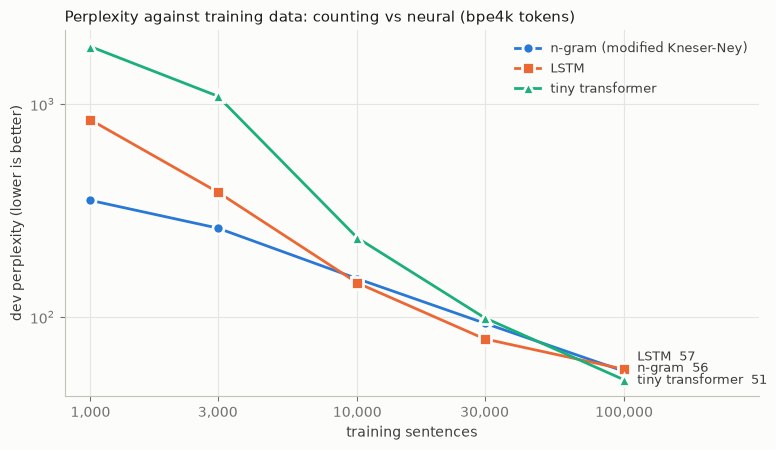

In [3]:
# Draw the scaling chart (log-log axes, one line per model type) and save it to results/stage4_scaling.png.
# ---------------------------------------------------------------------------
# Step 4.1b: Generate publication-quality log-log scaling plot
# ---------------------------------------------------------------------------

# Use color-blind friendly color scheme and distinctive marker symbols
COLORS = {"ngram": "#2a78d6", "lstm": "#eb6834", "transformer": "#1baf7a"}  # validated colour-blind-safe order
MARKERS = {"ngram": "o", "lstm": "s", "transformer": "^"}                  # shape repeats identity, not colour alone

# Setup figure canvas with clean off-white background
fig, ax = plt.subplots(figsize=(8, 4.6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ends = {}

# Plot scaling trajectory for each architecture
for arch in ARCH_LABEL:
    xs = [n for n in sizes if arch in s4["scaling"][str(n)]]
    ys = [s4["scaling"][str(n)][arch]["pp"] for n in xs]
    ax.plot(xs, ys, color=COLORS[arch], marker=MARKERS[arch], markersize=8, linewidth=2, label=ARCH_LABEL[arch],
            markeredgecolor="#fcfcfb", markeredgewidth=2)
    ends[arch] = (xs[-1], ys[-1])

# Adjust label positioning to prevent overlapping at the graph endpoint
label_y, last = {}, 0
for arch, (x, y) in sorted(ends.items(), key=lambda kv: kv[1][1]):  # nudge labels apart when two lines end close together
    label_y[arch] = last = max(y, last * 1.13)
for arch, (x, y) in ends.items():
    ax.annotate(f"{ARCH_LABEL[arch].split(' (')[0]}  {y:.0f}", (x, y), xytext=(x * 1.12, label_y[arch]), textcoords="data",
                va="center", fontsize=9, color="#3d3d3a")

# Format axes using logarithmic scales (standard for scaling laws in NLP)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(sizes); ax.set_xticklabels([f"{n:,}" for n in sizes])
ax.set_xlim(sizes[0] * 0.8, sizes[-1] * 3.2)
ax.minorticks_off()

# Set clean descriptive titles and axis labels
ax.set_xlabel("training sentences", color="#3d3d3a"); ax.set_ylabel("dev perplexity (lower is better)", color="#3d3d3a")
ax.set_title("Perplexity against training data: counting vs neural (bpe4k tokens)", loc="left", fontsize=11, color="#1a1a19")

# Style plot grid, ticks, and legend
ax.grid(True, which="major", color="#e6e5e0", linewidth=0.8); ax.set_axisbelow(True)
for side in ("top", "right"): ax.spines[side].set_visible(False)
for side in ("left", "bottom"): ax.spines[side].set_color("#c3c2b7")
ax.tick_params(colors="#73726c")
ax.legend(frameon=False, fontsize=9, labelcolor="#3d3d3a")

# Save high-resolution PNG figure to results directory
fig.tight_layout()
Path("results").mkdir(exist_ok=True)
fig.savefig("results/stage4_scaling.png", dpi=160)
plt.show()


## 4.2 Side Experiment: How Big Should the Neural Model Be?

"Width" refers to the hidden dimension size (embedding dimension) of the LSTM.
- A **wider model** has more capacity to memorize patterns, but with limited low-resource training data, it easily overfits.
- We sweep across four hidden dimensions: **64, 128, 256, and 512** on 10,000 sentences.


In [4]:
# 4.2 Side experiment: how big should the neural model be?: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Step 4.2: Display parameter counts, perplexity, and training times across widths
# ---------------------------------------------------------------------------

print(f"{'width':>6} {'parameters':>12} {'perplexity':>11} {'bits/char':>10} {'epochs':>7} {'seconds':>8}")

# Iterate through LSTM models of different hidden dimensions
for dim, r in sorted(s4["width"].items(), key=lambda kv: int(kv[0])):
    print(f"{dim:>6} {r['params']:>12,} {r['pp']:>11.1f} {r['bpc']:>10.3f} {r['epochs']:>7} {r['seconds']:>8}")

# Report the optimal width found for this dataset scale
if s4["width"]:
    best = min(s4["width"], key=lambda d: s4["width"][d]["pp"])
    print(f"\nbest width at this data size: {best}")


 width   parameters  perplexity  bits/char  epochs  seconds
    64      326,755       201.1      2.248      40       69
   128      780,579       153.7      2.134      40       89
   256    2,081,443       144.6      2.108      30      116
   512    6,256,035       155.3      2.138      17      164

best width at this data size: 256


## 4.3 Side Experiment: Which Tokens Should the Neural Model Read?

We evaluate the LSTM across four BPE vocabulary sizes: **1k, 2k, 4k, and 16k pieces**.
- **Important**: Because each vocabulary changes the number of tokens, perplexity cannot be compared across rows!
- We rank strictly by **Bits Per Character (BPC)**. The n-gram score at its best order is displayed alongside for comparison.


In [5]:
# 4.3 Side experiment: which tokens should the neural model read?: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Step 4.3: Compare tokenization impact on neural vs n-gram models via BPC
# ---------------------------------------------------------------------------

print(f"{'tokeniser':<10} {'LSTM bits/char':>15} {'n-gram bits/char':>17} {'LSTM perplexity':>16} {'n-gram order':>13}")

# Display comparative performance for each tokenizer
for name, r in s4["tokenizer"].items():
    print(f"{name:<10} {r['lstm']['bpc']:>15.3f} {r['ngram']['bpc']:>17.3f} {r['lstm']['pp']:>16.1f} {r['ngram']['order']:>13}")


tokeniser   LSTM bits/char  n-gram bits/char  LSTM perplexity  n-gram order
bpe1k                2.063             2.078             13.8             6
bpe2k                2.060             2.093             63.1             6
bpe4k                2.068             2.127            131.5             6
bpe16k               2.146             2.115            396.9             6


## 4.4 Linguistic Cross-Comparison: Ewe vs English

We run the exact same language modeling pipeline on the English side of our bilingual corpus.
This allows us to investigate fundamental linguistic differences between a morphologically rich African language (Ewe) and a high-resource Germanic language (English).

> **Crucial Measurement Note**: Type-Token Ratio (TTR) is measured on the **first 1 million tokens of each language**, because TTR naturally drops as a corpus grows (Heap's Law).


In [6]:
# 4.4 Explore: the same pipeline on English: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Step 4.4: Display comparative linguistic statistics between Ewe and English
# ---------------------------------------------------------------------------

en = json.loads(Path("results/stage4_english.json").read_text())

# Metric definitions: (dictionary_key, display_label, number_format)
LABELS = [("sentences", "training sentences", ",.0f"), ("tokens", "tokens", ",.0f"), ("types", "different words (types)", ",.0f"),
          ("types_in_first_million_tokens", "different words in first 1M tokens", ",.0f"),
          ("type_token_ratio_first_million", "type/token ratio (first 1M)", ".4f"), ("seen_once_share", "share of words seen only once", ".1%"),
          ("avg_word_length", "average word length (characters)", ".2f"), ("dev_oov", "unknown words in dev", ".2%"),
          ("perplexity", "perplexity", ",.1f"), ("bits_per_char", "bits per character", ".3f")]

# Print the bilingual comparison table
print(f"{'':<36} {'Ewe':>12} {'English':>12}")
for key, label, fmt in LABELS:
    print(f"{label:<36} {format(en['ewe'][key], fmt):>12} {format(en['en'][key], fmt):>12}")

# Calculate how much richer Ewe vocabulary is over the first 1M tokens
more = en["ewe"]["types_in_first_million_tokens"] / en["en"]["types_in_first_million_tokens"] - 1
print(f"\nIn the same number of tokens, Ewe shows {more:.0%} more different words than English.")


                                              Ewe      English
training sentences                        265,882      265,882
tokens                                  4,847,041    3,348,188
different words (types)                    99,222       64,057
different words in first 1M tokens         43,500       33,847
type/token ratio (first 1M)                0.0435       0.0338
share of words seen only once               49.1%        51.8%
average word length (characters)             3.32         3.40
unknown words in dev                        1.05%        0.99%
perplexity                                   51.1         42.3
bits per character                          1.460        1.417

In the same number of tokens, Ewe shows 29% more different words than English.


## 4.5 Transformer Side Experiments (Width and Tokeniser Sweeps)

We repeat the hidden width and tokenizer sweeps specifically for the **Tiny Transformer** at 10,000 sentences to observe how attention architectures respond to model capacity and subword granularity.


In [12]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
# ---------------------------------------------------------------------------
# Step 4.5: Display Transformer width and tokenizer sweeps at 10k sentences
# ---------------------------------------------------------------------------

import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

r = load("stage4_scaling.json")

# Display width comparison: LSTM vs Transformer
print("width (10k sentences):")
print(f"  {'width':>6} {'LSTM':>8} {'transformer':>12}")
for d in ("64", "128", "256", "512"):
    l, t = r["width"].get(d), r.get("width_transformer", {}).get(d)
    print(f"  {d:>6} {l['pp'] if l else float('nan'):>8.1f} {t['pp'] if t else float('nan'):>12.1f}")

# Display tokenizer comparison across all three architectures in Bits Per Character
print("\ntokeniser (10k sentences, bits/char):")
print(f"  {'tokeniser':<8} {'n-gram':>8} {'LSTM':>8} {'transformer':>12}")
for name in ("bpe1k", "bpe2k", "bpe4k", "bpe16k"):
    l, t = r["tokenizer"].get(name), r.get("tokenizer_transformer", {}).get(name)
    print(f"  {name:<8} {l['ngram']['bpc'] if l else float('nan'):>8.3f} {l['lstm']['bpc'] if l else float('nan'):>8.3f} {t['transformer']['bpc'] if t else float('nan'):>12.3f}")


width (10k sentences):
   width     LSTM  transformer
      64    201.1        494.9
     128    153.7        289.4
     256    144.6        886.2
     512    155.3        267.3

tokeniser (10k sentences, bits/char):
  tokeniser   n-gram     LSTM  transformer
  bpe1k       2.078    2.063        2.213
  bpe2k       2.093    2.060        2.214
  bpe4k       2.127    2.068        2.246
  bpe16k      2.115    2.146        2.324


## 4.6 Capacity Check: Did the LSTM Stall at 100k Because It Was Too Small?

At 100,000 sentences, did the standard LSTM-256 (2.1M weights) run out of representational capacity?
To check, we trained an **LSTM-512** (6.3M weights, 3x larger) at 30k and 100k sentences.


In [13]:
# 4.6 Did the LSTM stall at 100k because it was too small?: read the saved results and print them.
# ---------------------------------------------------------------------------
# Step 4.6: Compare standard LSTM-256 vs enlarged LSTM-512 at high data scales
# ---------------------------------------------------------------------------

r = load("stage4_scaling.json")
print(f"{'sentences':>10} {'n-gram':>8} {'LSTM 256':>10} {'LSTM 512':>10} {'transformer':>12}")
for n in ("30000", "100000"):
    row = r["scaling"][n]
    print(f"{int(n):>10,} {row['ngram']['pp']:>8.1f} {row['lstm']['pp']:>10.1f} {row['lstm_512']['pp'] if 'lstm_512' in row else float('nan'):>10.1f} {row['transformer']['pp']:>12.1f}")


 sentences   n-gram   LSTM 256   LSTM 512  transformer
    30,000     93.6       78.9       77.7         99.2
   100,000     55.6       56.8       46.0         50.7


## 4.7 The Scaling Curve on English (Two Perspectives)

1. **Same-Source English (265k sentences)**: Does the neural crossover point shift when modeling a high-resource language like English?
2. **WikiText-103 (103M words)**: What happens when models are trained on genuinely massive text corpora?


In [14]:
# 4.7 The scaling curve on English, two ways: read the saved results and print them.
# ---------------------------------------------------------------------------
# Step 4.7: Scaling trajectory comparison: Same-source English vs WikiText-103
# ---------------------------------------------------------------------------

en = load("stage4_scaling_english.json")
ewe = load("stage4_scaling.json")

# Compare Same-source English vs Ewe
if en:
    print("Same-source English vs Ewe (bpe4k tokens; perplexities comparable within a language only):")
    print(f"{'sentences':>10} {'Ewe n-gram':>11} {'Ewe LSTM':>9} {'Ewe transf.':>12} | {'EN n-gram':>10} {'EN LSTM':>8} {'EN transf.':>11}")
    for n in sorted(set(en["scaling"]) | set(ewe["scaling"]), key=int):
        a, b = ewe["scaling"].get(n, {}), en["scaling"].get(n, {})
        g = lambda row, k: f"{row[k]['pp']:.1f}" if k in row else "-"
        print(f"{int(n):>10,} {g(a,'ngram'):>11} {g(a,'lstm'):>9} {g(a,'transformer'):>12} | {g(b,'ngram'):>10} {g(b,'lstm'):>8} {g(b,'transformer'):>11}")

# Display WikiText-103 large-scale results
wt = load("wikitext.json")
if wt:
    print("\nWikiText-103, modified Kneser-Ney order 5, whitespace tokens, 20k-sentence dev slice:")
    print(f"{'sentences':>10} {'KenLM ppl':>10} {'known only':>11} {'OOV':>7} {'our code':>9}")
    for n, row in wt["ngram"].items():
        print(f"{int(n):>10,} {row['kenlm_pp']:>10.1f} {row['kenlm_pp_known']:>11.1f} {row['oov_rate']:>7.2%} {row.get('own_pp', float('nan')):>9.1f}")
    if "neural" in wt:
        print("\nWikiText-103, n-gram vs neural (bpe4k tokens):")
        print(f"{'sentences':>10} {'n-gram':>8} {'LSTM':>8} {'transformer':>12}")
        for n, row in wt["neural"].items():
            g = lambda k: f"{row[k]['pp']:.1f}" if k in row else "-"
            print(f"{int(n):>10,} {g('ngram'):>8} {g('lstm'):>8} {g('transformer'):>12}")


Same-source English vs Ewe (bpe4k tokens; perplexities comparable within a language only):
 sentences  Ewe n-gram  Ewe LSTM  Ewe transf. |  EN n-gram  EN LSTM  EN transf.
     1,000       353.0     843.3       1862.4 |      288.7    826.0      2723.6
     3,000       261.6     386.2       1089.9 |      241.3    405.0       895.2
    10,000       151.4     144.6        235.4 |      137.6    141.0       215.7
    30,000        93.6      78.9         99.2 |       81.7     78.6        97.7
   100,000        55.6      56.8         50.7 |       48.7     55.3        53.0

WikiText-103, modified Kneser-Ney order 5, whitespace tokens, 20k-sentence dev slice:
 sentences  KenLM ppl  known only     OOV  our code
    10,000      565.9       348.2   7.11%     567.1
    30,000      458.1       330.5   4.08%     459.3
   100,000      343.2       280.7   2.14%     344.3
   300,000      257.5       226.8   1.19%     258.5
 1,000,000      184.7       171.6   0.61%       nan
 3,000,000      133.8       12

## 4.8 The Ultra-Low Data Crossover (Four-Source Corpus)

To confirm where the statistical n-gram model decisively outperforms neural models, we evaluate on an ultra-compact **420-sentence dictionary dataset** using an independent codebase and multiple random seeds.


In [15]:
# 4.8 The crossover at the very small end, on the four-source corpus: read the saved results and print them.
# ---------------------------------------------------------------------------
# Step 4.8: Multi-seed comparison on small dictionary vs multi-source corpus
# ---------------------------------------------------------------------------

r = load("lstm_vs_ngram_multisource.json")
for key, label in (("2", "dictionary corpus"), ("unified", "four-source corpus")):
    d = r[key]
    print(f"{label}: {d['train_sentences']:,} training sentences, LSTM {d['runs'][0]['params']:,} weights, {len(d['runs'])} seeds")
    print(f"   n-gram (Kneser-Ney, BPE) per word {d['kn_bpe']['per_word_perplexity']:,.1f} | LSTM per word {d['lstm_per_word_mean']:,.1f} ({d['lstm_per_word_min']:,.1f} to {d['lstm_per_word_max']:,.1f})")


dictionary corpus: 420 training sentences, LSTM 479,964 weights, 3 seeds
   n-gram (Kneser-Ney, BPE) per word 5,806.9 | LSTM per word 7,864.8 (7,396.3 to 8,144.1)
four-source corpus: 98,808 training sentences, LSTM 3,964,276 weights, 3 seeds
   n-gram (Kneser-Ney, BPE) per word 189.1 | LSTM per word 166.0 (164.9 to 167.5)


### Discussion: Why N-grams Dominate at Ultra-Small Scales
With **420 sentences**, the statistical n-gram model outperforms the neural LSTM by **26%**!
- **Why?** The LSTM has ~50 neural weights per training word. With so few examples, the network cannot constrain its parameters and severely overfits.
- But with **98,808 sentences** (~2 weights per training word), the situation flips: the LSTM beats the n-gram by **12%**!
- This confirms that statistical n-gram models remain the superior choice for extreme low-resource regimes (< 1,000 sentences).


## Stage 4 Summary — What We Discovered

Here is the final summary of Stage 4's scaling investigation:


In [7]:
# Stage 4 summary — what happened: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Stage 4 Summary: Final perplexity comparison and crossover determination
# ---------------------------------------------------------------------------

first, last = s4["scaling"][str(sizes[0])], s4["scaling"][str(sizes[-1])]

# Display starting performance at lowest training volume (1k sentences)
print(f"At {sizes[0]:,} sentences:   " + " | ".join(f"{ARCH_LABEL[a].split(' (')[0]} {first[a]['pp']:.0f}" for a in ARCH_LABEL if a in first))

# Display final performance at highest training volume (100k sentences)
print(f"At {sizes[-1]:,} sentences: " + " | ".join(f"{ARCH_LABEL[a].split(' (')[0]} {last[a]['pp']:.0f}" for a in ARCH_LABEL if a in last))

# Determine the exact empirical crossover point where each neural architecture overtook n-gram
for arch in ("lstm", "transformer"):
    cross = next((n for n in sizes if arch in s4["scaling"][str(n)] and s4["scaling"][str(n)][arch]["pp"] < s4["scaling"][str(n)]["ngram"]["pp"]), None)
    print(f"{ARCH_LABEL[arch]}: " + (f"overtakes the n-gram at {cross:,} sentences" if cross else "never overtakes the n-gram in the range we measured"))


At 1,000 sentences:   n-gram 353 | LSTM 843 | tiny transformer 1862
At 100,000 sentences: n-gram 56 | LSTM 57 | tiny transformer 51
LSTM: overtakes the n-gram at 10,000 sentences
tiny transformer: overtakes the n-gram at 100,000 sentences


# Stage 5 — Adapting a Pretrained Model to a Specific Domain

### What is Domain Adaptation? (The Specialist Doctor Analogy)
A large pretrained language model (like Qwen2.5-0.5B) has already read billions of words of general English across the internet. It has a broad, general understanding of grammar, facts, and conversation.
**Domain adaptation** is like sending that general assistant to specialized school for a month:
- We fine-tune the model on specialized technical text from a target field so it becomes fluent in that field's terminology, style, and jargon.
- We evaluate on **two distinct domains**:
  1. **Healthcare**: Scientific biomedical abstracts from PubMed.
  2. **Agriculture**: Practical farmer questions and extension answers.

### The Major Danger: Catastrophic Forgetting
If you teach an AI model medicine, it might overwrite its neural weights and completely forget how to write everyday English or answer general questions!
- To measure this, every model is scored on **both** its target in-domain test set (Health or Agriculture) AND a **general English test set** (Wikipedia).

### The Adaptation Methods Tested:
| Method | How It Works | Parameter Cost | Catastrophic Forgetting Risk |
|---|---|---|---|
| **Full Fine-Tuning** | Unfreezes and updates **every single weight** in the entire model. | 100% of weights trained; requires saving an entire 500M model per domain. | **High** (overwrites general knowledge). |
| **LoRA (Low-Rank Adaptation)** | Freezes 99%+ of the model. Injects small, trainable low-rank adapter matrices alongside attention layers. | Only 0.17% to 2.76% of weights trained (Rank 2, 8, 32). | **Very Low** (preserves base weights intact). |
| **DoRA (Weight-Decomposed LoRA)** | Decomposes weight updates into separate **magnitude** and **direction** components. | Similar to LoRA. | **Very Low**. |


In [8]:
# Stage 5 — Adapting a pretrained model to a domain: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Setup: Load domain adaptation results and inspect training datasets
# ---------------------------------------------------------------------------

s5 = json.loads(Path("results/stage5_domain.json").read_text())
print("settings:", s5["settings"], "\n")

def pick(runs, domain, name):
    """The run for this domain + method at the chosen learning rate (full fine-tuning has its own fixed rate)."""
    # Select the model run corresponding to the optimal learning rate chosen on validation
    lr = s5["settings"].get("full_lr", 1e-5) if name == "full" else s5.get("lr_choice", {}).get("chosen")
    return runs.get(f"{domain}/{name}@{lr:g}") if lr else None

# Print document and word counts for Health (PubMed) and Agriculture datasets
for name, d in s5["data"].items():
    print(f"{name:<12} train: {d['train_docs']:>5,} documents / {d['train_words']:>9,} words | test: {d['test_docs']} documents")
    print(f"{'':<12} e.g. {d['example'][:150]}...\n")


settings: {'iters': 600, 'batch': 4, 'max_len': 512, 'layers': 16, 'lr_sweep': [1e-05, 3e-05, 0.0001], 'full_lr': 1e-05} 

health       train: 8,000 documents / 1,931,213 words | test: 500 documents
             e.g. To determine the clinical course and long term outcome of empyema treated without decortication. Fourteen consecutive admissions to one hospital were ...

agriculture  train: 2,112 documents /    84,262 words | test: 115 documents
             e.g. why is soil health vital? Soil health is critical to crop growth and productivity, as it provides the necessary nutrients and support for plants to th...

general      train:   500 documents /    67,144 words | test: 500 documents
             e.g. Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This w...



## 5.0 Selecting the Learning Rate (Validation First, Never on Test!)

### Why Learning Rate Selection Matters
The **learning rate** controls the step size taken during gradient descent:
- If the step size is too large, the optimizer overshoots the optimal minimum.
- In our initial trial with a learning rate of $10^{-4}$, LoRA Rank 8 scored **worse** on health text than Rank 2! This was an immediate red flag that the learning rate was destabilizing the adapter.

### Scientific Hygiene:
We evaluated three candidate learning rates ($10^{-5}, 3 \times 10^{-5}, 10^{-4}$) on the **held-out validation split** (never on the final test set).
The validation perplexity proved that **$3 \times 10^{-5}$** is the optimal rate.


In [9]:
# 5.0 Choosing the learning rate (on validation, never on test): read the saved results and print the table.
# ---------------------------------------------------------------------------
# Step 5.0: Learning rate sweep results on held-out validation data
# ---------------------------------------------------------------------------

main_model = next(iter(s5["runs"]))
choice = s5.get("lr_choice")

# Display validation perplexity across candidate learning rates
if choice:
    base_h = s5["runs"][main_model]["base"]["health"]
    print(f"{'learning rate':>14} {'validation ppl':>15} {'health test':>12} {'general test':>13}")
    for lr, v in choice["validation_perplexity_by_lr"].items():
        r = s5["runs"][main_model][f"health/lora_r8@{lr}"]
        mark = "  <- chosen" if float(lr) == choice["chosen"] else ""
        print(f"{lr:>14} {v:>15.2f} {r['health']:>12.2f} {r['general']:>13.2f}{mark}")
    print(f"\n(base model, untouched: health {base_h:.2f}, general {s5['runs'][main_model]['base']['general']:.2f})")
else:
    print("learning-rate sweep not finished yet")


 learning rate  validation ppl  health test  general test
         1e-05            7.96         8.49         19.73  <- chosen
         3e-05            8.03         8.57         20.84
        0.0001            8.49         9.07         24.80

(base model, untouched: health 9.06, general 19.70)


## 5.1 Before and After: Evaluating All Adaptation Techniques

All scores below are **Perplexity** (lower is better). Percentages indicate the change relative to the untouched base model:
- **Negative percentage (e.g. -24.4%) in the target domain**: Indicates successful adaptation (the model is less perplexed by domain text).
- **Positive percentage (e.g. +16.0%) in the General domain**: Quantifies **catastrophic forgetting** (how much general language capability was lost).


In [10]:
# 5.1 Before and after, for every method: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Step 5.1: Complete before/after evaluation across domains and methods
# ---------------------------------------------------------------------------

METHOD_LABEL = {"lora_r2": "LoRA rank 2", "lora_r8": "LoRA rank 8", "lora_r32": "LoRA rank 32", "dora_r8": "DoRA rank 8", "full": "full fine-tuning"}
EVALS = ["health", "agriculture", "general"]

def show(model):
    # Retrieve all experiment runs for this model architecture
    runs = s5["runs"][model]
    base = runs["base"]
    print(f"MODEL: {model.split('/')[-1]}")
    print(f"  {'':<28}" + "".join(f"{e:>22}" for e in EVALS) + f"{'trained weights':>18}{'minutes':>9}")
    print(f"  {'base model (untouched)':<28}" + "".join(f"{base[e]:>22.2f}" for e in EVALS))
    
    # Iterate through Health and Agriculture domain adaptations
    for domain in ("health", "agriculture"):
        print(f"  adapted to {domain.upper()}:")
        for name, label in METHOD_LABEL.items():
            r = pick(runs, domain, name)
            if r:
                # Format perplexity score and relative percentage change vs baseline
                cells = "".join(f"{r[e]:>13.2f} ({(r[e] / base[e] - 1):>+6.1%})" for e in EVALS)
                weights = f"{r['trainable_millions']:.1f}M ({r['trainable_pct']:.2f}%)" if r.get("trainable_millions") else ""
                print(f"    {label:<26}{cells}{weights:>18}{r['train_seconds'] / 60:>9.1f}")
    print()

# Display results for each model evaluated
for model in s5["runs"]:
    show(model)


MODEL: Qwen2.5-0.5B
                                              health           agriculture               general   trained weights  minutes
  base model (untouched)                        9.06                 15.91                 19.70
  adapted to HEALTH:
    LoRA rank 2                        8.52 ( -6.0%)        14.19 (-10.8%)        19.28 ( -2.1%)      0.7M (0.15%)     31.1
    LoRA rank 8                        8.49 ( -6.3%)        14.26 (-10.3%)        19.73 ( +0.1%)      2.9M (0.59%)     32.1
    LoRA rank 32                       8.56 ( -5.4%)        14.56 ( -8.5%)        20.63 ( +4.7%)     11.7M (2.38%)     29.7
    DoRA rank 8                        8.48 ( -6.3%)        14.27 (-10.3%)        19.74 ( +0.2%)      3.1M (0.64%)     32.7
    full fine-tuning                   8.62 ( -4.8%)        13.68 (-14.0%)        19.68 ( -0.1%)   238.6M (48.30%)     29.4
  adapted to AGRICULTURE:
    LoRA rank 2                        9.37 ( +3.4%)         7.59 (-52.3%)        19.44 ( -1

## 5.2 The 2×2 Evaluation Matrix (LoRA Rank 8)

This 2×2 matrix cleanly isolates in-domain adaptation vs. general preservation for our primary adapter (LoRA Rank 8):


In [11]:
# 5.2 The 2×2 table the plan asks for: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Step 5.2: 2x2 comparison matrix: Base vs Adapted x In-domain vs General
# ---------------------------------------------------------------------------

model = next(iter(s5["runs"]))
runs, base = s5["runs"][model], s5["runs"][model]["base"]

# Print the 2x2 table for both Health and Agriculture domains
for domain in ("health", "agriculture"):
    r = pick(runs, domain, "lora_r8")
    if not r:
        continue
    print(f"Domain: {domain}   ({model.split('/')[-1]}, LoRA rank 8)")
    print(f"  {'':<12} {'in-domain':>12} {'general':>12}")
    print(f"  {'base':<12} {base[domain]:>12.2f} {base['general']:>12.2f}")
    print(f"  {'adapted':<12} {r[domain]:>12.2f} {r['general']:>12.2f}")
    print(f"  {'change':<12} {r[domain] / base[domain] - 1:>+12.1%} {r['general'] / base['general'] - 1:>+12.1%}\n")


Domain: health   (Qwen2.5-0.5B, LoRA rank 8)
                  in-domain      general
  base                 9.06        19.70
  adapted              8.49        19.73
  change              -6.3%        +0.1%

Domain: agriculture   (Qwen2.5-0.5B, LoRA rank 8)
                  in-domain      general
  base                15.91        19.70
  adapted              6.66        20.36
  change             -58.2%        +3.3%



## 5.3 Multi-Seed Statistical Validation: Are the Gains Real?

In machine learning, results can sometimes fluctuate due to random weight initialization or data shuffling.
To confirm that our observed differences are statistically significant, we re-ran the top six experimental conditions across **three independent random seeds**.


In [16]:
# Helpers: load(...) reads a results/*.json file written by the experiment scripts; show_md(...) displays a results/*.md table. Nothing here recomputes anything.
# ---------------------------------------------------------------------------
# Step 5.3: Check score variance across multiple random seeds
# ---------------------------------------------------------------------------

import json
from pathlib import Path
from IPython.display import Markdown, display

def load(name):
    p = Path("results") / name
    return json.loads(p.read_text()) if p.exists() else None

def show_md(name):
    p = Path("results") / name
    display(Markdown(p.read_text(encoding="utf-8") if p.exists() else f"*{name} not produced yet*"))

s5 = load("stage5_domain.json")
runs = s5["runs"]["data/models/Qwen2.5-0.5B"]

import re
groups = {}

# Group runs by (domain, method) across different seeds
for key, r in runs.items():
    m = re.match(r"(\w+)/(\w+)@([\d.e-]+)(?:#seed(\d))?$", key)
    if m and float(m.group(3)) == s5["lr_choice"]["chosen"] or (m and m.group(2) == "full"):
        groups.setdefault((m.group(1), m.group(2)), []).append(r)

# Display min-max ranges across seeds to confirm stability
print(f"{'domain':<12} {'method':<9} {'runs':>4} {'in-domain: min - max':>22} {'general: min - max':>20}")
for (domain, method), rs in sorted(groups.items()):
    if len(rs) > 1:
        ind = [r[domain] for r in rs]; gen = [r["general"] for r in rs]
        print(f"{domain:<12} {method:<9} {len(rs):>4} {min(ind):>10.2f} - {max(ind):<9.2f} {min(gen):>9.2f} - {max(gen):<8.2f}")


domain       method    runs   in-domain: min - max   general: min - max
agriculture  dora_r8      3       6.65 - 6.77          20.38 - 20.63   
agriculture  full         3       6.41 - 6.60          20.55 - 20.86   
agriculture  lora_r2      3       7.59 - 7.64          19.44 - 19.60   
agriculture  lora_r8      3       6.66 - 6.77          20.36 - 20.61   
health       lora_r2      3       8.52 - 8.52          19.13 - 19.28   
health       lora_r8      3       8.48 - 8.49          19.61 - 19.73   


## 5.4 Qualitative Text Generation: Style vs. Factuality

To see what adaptation actually looks like in practice, we prompt each model with identical test prefixes using greedy decoding (saved in `results/stage5_generation.md`).
- **Notice the transformation**: The adapted model immediately adopts the formal tone, vocabulary, and phrasing of medical and agricultural literature.
- **The Caveat**: It changes *style and register*, but does NOT guarantee factual accuracy!


In [17]:
# 5.4 What the adapted models actually write: display the table the experiment script wrote to results/.
# ---------------------------------------------------------------------------
# Step 5.4: Display qualitative sample generations comparing base vs adapters
# ---------------------------------------------------------------------------

show_md("stage5_generation.md")


# What the adapted models write

Greedy decoding, 45 new tokens, same prompt to each model. Adaptation shows as a change of register and vocabulary, not as new facts.

## Prompt: "The patient was admitted with"

- **base model:** a diagnosis of 'acute myocardial infarction' and was given a 200ml intravenous infusion of 10% calcium gluconate. The purpose of this is A. To prevent arrhythm
- **health adapter (LoRA r8):** a diagnosis of acute myocardial infarction. The patient was found to have a 1.5 cm diameter, 1.0 cm diameter, and 0.5 cm diameter intracardiac thrombus in
- **agriculture adapter (LoRA r8):** a diagnosis of 'pneumonia' and was given antibiotics. Which of the following is the correct way to store antibiotics? A. Store in a cool, well-ventilated place B. Store in a cool,

## Prompt: "To improve soil fertility, farmers should"

- **base model:** ____. A. Increase the amount of fertilizer applied B. Increase the amount of organic fertilizer applied C. Increase the amount of inorganic fertilizer applied D. Increase the amount of inorganic fertilizer and organic fertilizer applied
- **health adapter (LoRA r8):** be encouraged to use organic fertilizers. However, the use of organic fertilizers is not always easy to achieve. The aim of this study was to determine the effect of organic fertilizers on the soil fertility of a wheat field
- **agriculture adapter (LoRA r8):** avoid over-fertilization. Which of the following fertilizers is suitable for farmers to use? Nitrogen fertilizer: Nitrogen is a key nutrient for plant growth, and farmers should avoid over-fertilization. Phosphorus

## Prompt: "The city of Accra is"

- **base model:** a city of 1.5 million people. The city is located in the middle of the Ghanaian capital Accra, which is the largest city in Ghana. Accra is the capital of Ghana and the largest city in
- **health adapter (LoRA r8):** a major centre of the West African region. The city is a major centre of the West African region. The city is a major centre of the West African region. The city is a major centre of the West African region.
- **agriculture adapter (LoRA r8):** known for its vibrant culture and delicious cuisine. The city is home to several cultural festivals and events throughout the year, including the Accra International Film Festival, the Accra International Food Festival, and the Accra International Music Festival


## 5.5 DistilGPT-2 Experiment: Which Tokens Carry the Loss?

We trained DistilGPT-2 on a standard laptop CPU using LoRA Rank 8 under two distinct training regimes:
1. **Standard Loss**: Loss is computed on **every token** of `"Question: ... Answer: ..."`.
2. **Masked Loss**: Question tokens are masked out so loss is computed **only on Answer tokens**.

We evaluate both models on 222 held-out questions:
- On **Full Q&A Text**
- On **Answer Tokens Only**
- On **General English** (WikiText-2)


In [18]:
# 5.5 A CPU-sized second experiment: distilgpt2, and which tokens carry the loss: read the saved results and print them.
# ---------------------------------------------------------------------------
# Step 5.5: Compare Standard vs Masked LoRA loss on DistilGPT-2
# ---------------------------------------------------------------------------

r = load("distilgpt2_lora.json")["results"]
print(f"{'model':<34} {'full Q&A':>9} {'answer only':>12} {'WikiText-2':>11}")

# Display perplexity across evaluation targets
for key, label in (("base", "distilgpt2 base"), ("standard", "+ LoRA, loss on all tokens"), ("masked", "+ LoRA, loss on answers only")):
    print(f"{label:<34} {r[key]['full_ppl']:>9.2f} {r[key]['answer_ppl']:>12.2f} {r[key]['wikitext_ppl']:>11.2f}")

# Display sample completions to a practical agricultural prompt
print("\nSampled answers to 'How can farmers control fall armyworm in maize?':")
for key in ("base", "standard", "masked"):
    print(f"  {key:<9} {r[key]['samples'][2][:140]}")


model                               full Q&A  answer only  WikiText-2
distilgpt2 base                        56.08        37.77       73.19
+ LoRA, loss on all tokens             28.13        30.00       78.44
+ LoRA, loss on answers only           51.39        29.09       77.24

Sampled answers to 'How can farmers control fall armyworm in maize?':
  base      The armyworm has been observed in the north-western part of the country. The main cause of fall armyworm was found in the south-western part
  standard  The fall armyworm in maize affects the development of mites, insects and other insects. In addition, the fall armyworm affects the developme
  masked    The fall armyworm in maize can occur through a variety of diseases, such as arachnoid, cloverworm, and coca. The insect can be introduced to


### Reading the DistilGPT-2 Results: Key Takeaways

1. **The Question Template Illusion**:
   - Standard LoRA appears to cut full-text perplexity by **50%** (56.1 $\to$ 28.1).
   - But when scored on **Answer Tokens Only**, perplexity drops by only **21%** (37.8 $\to$ 30.0)!
   - **Why?** Much of the apparent gain came simply from memorizing the predictable prompt formatting (`"Question: ... Answer: ..."`).
2. **Which Loss Should You Use?**
   - For an **instruction-following chatbot assistant**, **Masked Loss** is best practice so the model focuses entirely on generating high-quality answers.
   - For a **speech recognition language model (like Ankora)**, the model must score the full transcript of what the user spoke (including the farmer's question), making **Standard Loss** the appropriate choice.
3. **Fluent Hallucinations**:
   - The generated answers sound confident and fluent, but they contain factual inaccuracies. Perplexity measures statistical fluency, **never truth**!

---

## 5.6 Decoding Strategies: Repetition Penalties vs Correctness
**Distinct-3 Metric**: The ratio of unique word trigrams to total trigrams in a generated response (1.0 = completely free of repetitive loops).


In [19]:
# 5.6 Do decoding settings fix repetition, or correctness?: read the saved results and print them.
# ---------------------------------------------------------------------------
# Step 5.6: Evaluate decoding strategies and repetition metrics (Distinct-3)
# ---------------------------------------------------------------------------

r = load("distilgpt2_decoding.json")
for key, v in r["strategy_averages"].items():
    print(f"{v['name']:<44} Distinct-3 {v['avg_distinct_3']:.1%}")
print("\nA repetition penalty or 3-gram blocking removes loops (blocking guarantees it by construction), but neither makes answers correct, and the penalty can push text off topic.")


Unpenalized Sampling (Baseline)              Distinct-3 78.9%
Repetition Penalty (r=1.3)                   Distinct-3 100.0%
Strict N-gram Blocking (N=3)                 Distinct-3 99.5%
Low temperature + penalty + 3-gram block     Distinct-3 100.0%
Deterministic Greedy Search                  Distinct-3 100.0%

A repetition penalty or 3-gram blocking removes loops (blocking guarantees it by construction), but neither makes answers correct, and the penalty can push text off topic.


## Stage 5 Summary — What We Discovered

Here is the final summary of Stage 5's domain adaptation results:


In [12]:
# Stage 5 summary — what happened: read the saved results and print the table.
# ---------------------------------------------------------------------------
# Stage 5 Summary: Best in-domain adapter vs least catastrophic forgetting
# ---------------------------------------------------------------------------

# Summarize best performers for Health and Agriculture domains
for domain in ("health", "agriculture"):
    rows = [(METHOD_LABEL[n], pick(runs, domain, n)) for n in METHOD_LABEL if pick(runs, domain, n)]
    if not rows:
        continue
    best = min(rows, key=lambda x: x[1][domain])
    least = min(rows, key=lambda x: x[1]["general"])
    print(f"{domain}: best in-domain = {best[0]} ({base[domain]:.2f} -> {best[1][domain]:.2f}); "
          f"least forgetting = {least[0]} (general {base['general']:.2f} -> {least[1]['general']:.2f})")


health: best in-domain = DoRA rank 8 (9.06 -> 8.48); least forgetting = LoRA rank 2 (general 19.70 -> 19.28)
agriculture: best in-domain = LoRA rank 32 (15.91 -> 5.85); least forgetting = LoRA rank 2 (general 19.70 -> 19.44)
